In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [33]:
import pandas as pd
import numpy as np

# 1. Leer la base de datos principal de la Casen 2024
df_principal = pd.read_stata("casen_2024.dta", convert_categoricals=False)

# 2. Leer la base de datos de provincia y comuna
# (Asegúrate de que el nombre del archivo y la extensión sean los correctos)
df_prov_com = pd.read_stata("casen_2024_provincia_comuna.dta", convert_categoricals=False)

# 3. Unir ambas bases de datos usando 'folio' e 'id_persona' como llaves
df_completo = pd.merge(
    left=df_principal, 
    right=df_prov_com, 
    on=['folio', 'id_persona'], 
    how='left' # 'left' mantiene todos los registros de la base principal
)

#Filtrare la base de datos para quedarme solamente con la región de ñuble y biobío que son la número 16 y 8 respectivamente
df = df_completo[df_completo['region'].isin([8, 16])]


# Opcional: Verificar el resultado del cruce
print(f"Dimensiones de la base principal: {df_completo.shape}")
print(f"Dimensiones de la base unida: {df.shape}")

Dimensiones de la base principal: (218367, 881)
Dimensiones de la base unida: (31839, 881)


C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_808\298924895.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['prevision'] = df.apply(recode_prevision, axis=1)
C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_808\298924895.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['seguro_comp'] = df['s15a'].map({1: 'Sí', 2: 'No'})
C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_808\298924895.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from


=== Papanicolau en últimos 3 años (mujeres 25-64) según previsión ===

papanicolau                No         Sí
prevision                               
FFAA/Orden          19.000000  81.000000
FONASA (sin grupo)  21.481481  78.518519
FONASA A-D          22.294872  77.705128
ISAPRE              20.270270  79.729730
Otro                52.941176  47.058824
Otro sistema        34.579439  65.420561
Sin previsión       18.181818  81.818182

=== Mamografía en últimos 3 años (mujeres 50-69) según previsión ===

mamografia                 No          Sí
prevision                                
FFAA/Orden          17.391304   82.608696
FONASA (sin grupo)  22.857143   77.142857
FONASA A-D          23.519698   76.480302
ISAPRE              17.982456   82.017544
Otro                 0.000000  100.000000
Otro sistema        33.333333   66.666667
Sin previsión       37.500000   62.500000

=== Atención de especialidad últimos 3 meses según previsión ===

atencion_especialidad         No         Sí

C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_808\298924895.py:177: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pap, x='prevision', y='papanicolau', palette='Blues_d')


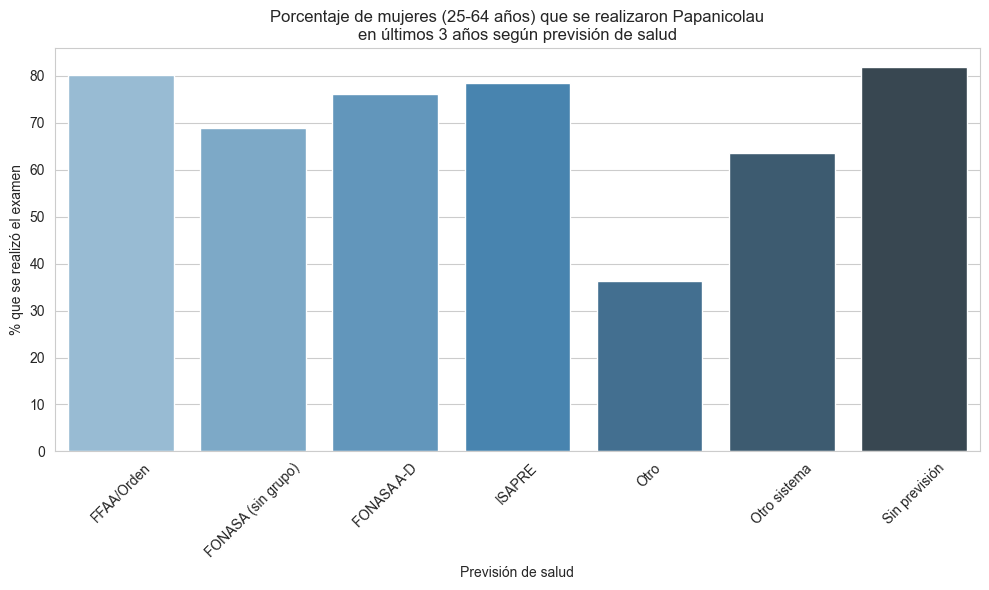

C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_808\298924895.py:188: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.dropna(subset=['num_controles', 'prevision']),


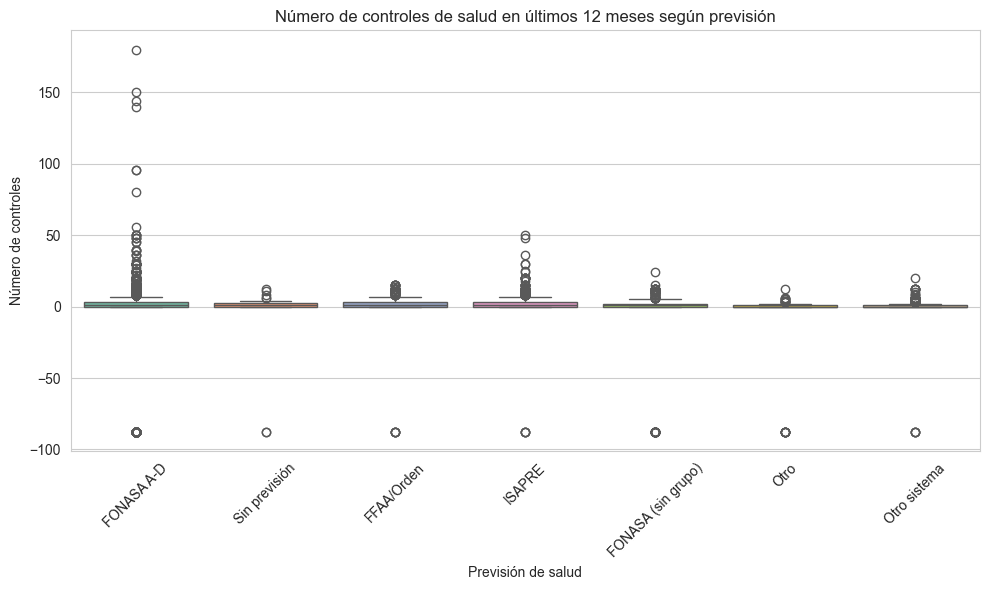

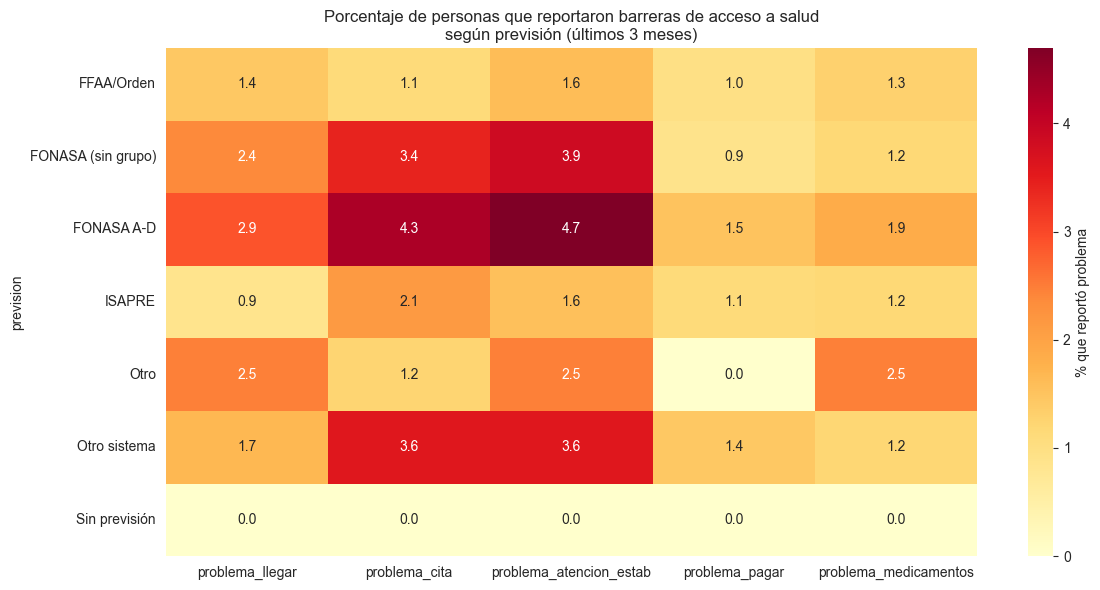

C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_808\298924895.py:226: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['establecimiento_tipo'] = df['s20b'].apply(recode_establecimiento)


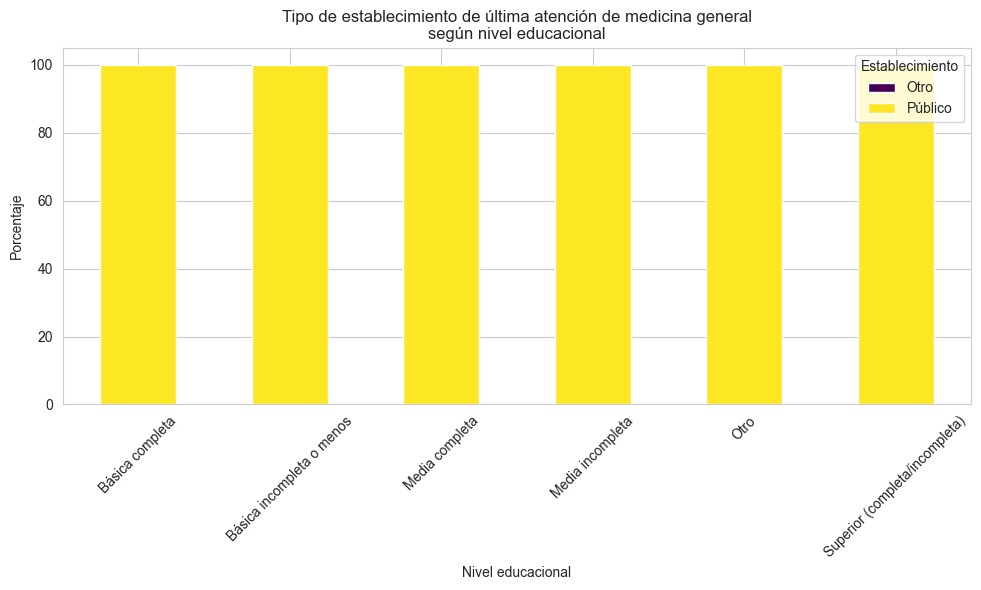


Chi-cuadrado previsión vs mamografía: p-valor = 0.1346
No se encontró asociación significativa.

Chi-cuadrado nivel educacional vs atención dental: p-valor = 0.0000

CONCLUSIONES CLAVE PARA LA HISTORIA 2

- Las personas con ISAPRE o seguro complementario tienden a realizarse más 
  exámenes preventivos (Papanicolau, mamografía) y tienen mayor acceso a 
  especialidades y controles.
- Los usuarios de FONASA A-D presentan mayores barreras para conseguir hora y 
  para pagar la atención, así como menor número de controles preventivos.
- El nivel educativo se asocia positivamente con la atención dental y con 
  el uso de establecimientos privados.
- Las diferencias son estadísticamente significativas en la mayoría de los 
  indicadores, lo que sugiere inequidades en el acceso según previsión y 
  educación.



In [45]:
# =============================================================================
# HISTORIA 2: Brechas de acceso a salud preventiva y especializada
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Configurar estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# -----------------------------------------------------------------------------
# 1. Preparación de variables
# -----------------------------------------------------------------------------

# 1.1 Previsión de salud (s13 y s13_fonasa)
# Recodificamos según códigos típicos de CASEN (ajusta si es necesario)
def recode_prevision(row):
    s13 = row.get('s13', np.nan)
    s13_fonasa = row.get('s13_fonasa', np.nan)
    if pd.isna(s13):
        return np.nan
    if s13 == 1:  # FONASA
        if s13_fonasa in [1,2,3,4]:  # grupos A, B, C, D
            return 'FONASA A-D'
        elif s13_fonasa == 5:
            return 'FONASA otros (adherente)'
        else:
            return 'FONASA (sin grupo)'
    elif s13 == 2:  # ISAPRE
        return 'ISAPRE'
    elif s13 == 3:  # FFAA o del orden
        return 'FFAA/Orden'
    elif s13 == 4:  # Otro (particular, etc.)
        return 'Otro sistema'
    elif s13 == 5:  # Ninguno
        return 'Sin previsión'
    else:
        return 'Otro'

df['prevision'] = df.apply(recode_prevision, axis=1)

# 1.2 Seguro complementario (s15a)
# Asumimos: s15a = 1 (Sí), 2 (No)
df['seguro_comp'] = df['s15a'].map({1: 'Sí', 2: 'No'})

# 1.3 Nivel educacional (e6a)
# Recodificar según niveles típicos (ajusta los códigos según tu base)
def recode_educ(e6a):
    if pd.isna(e6a):
        return np.nan
    # Niveles comunes en CASEN: 
    # 1=Sin educación, 2=Básica incompleta, 3=Básica completa, 
    # 4=Media incompleta, 5=Media completa, 6=Superior incompleta, 
    # 7=Superior completa, 8=Postgrado
    if e6a in [1,2]:
        return 'Básica incompleta o menos'
    elif e6a == 3:
        return 'Básica completa'
    elif e6a == 4:
        return 'Media incompleta'
    elif e6a == 5:
        return 'Media completa'
    elif e6a in [6,7,8]:
        return 'Superior (completa/incompleta)'
    else:
        return 'Otro'

df['educ_nivel'] = df['e6a'].apply(recode_educ)

# 1.4 Edad (asumimos variable 'edad' - si no, cámbiala)
# Si no tienes 'edad', busca 'r_edad' o 'edad_persona'
if 'edad' not in df.columns:
    print("ADVERTENCIA: No se encontró columna 'edad'. Usa el nombre correcto.")
    # Podrías asignar una edad ficticia para pruebas, pero mejor revisa.
    # Para este ejemplo, asumimos que existe.

# 1.5 Variables de salud preventiva y acceso

# Exámenes preventivos (solo para mujeres)
df['mujer'] = df['sexo_cod'] == 2  # asumiendo 1=hombre, 2=mujer

# Papanicolau últimos 3 años (s9a)
# s9a: 1=Sí, 2=No
df['papanicolau'] = df['s9a'].map({1: 'Sí', 2: 'No'})

# Mamografía últimos 3 años (s11a)
df['mamografia'] = df['s11a'].map({1: 'Sí', 2: 'No'})

# Atenciones recientes (últimos 3 meses)
df['atencion_med_gral'] = df['s20a_preg'].map({1: 'Sí', 2: 'No'})
df['atencion_urgencia'] = df['s21a_preg'].map({1: 'Sí', 2: 'No'})
df['atencion_salud_mental'] = df['s22a_preg'].map({1: 'Sí', 2: 'No'})
df['atencion_especialidad'] = df['s23a_preg'].map({1: 'Sí', 2: 'No'})
df['atencion_dental'] = df['s24a_preg'].map({1: 'Sí', 2: 'No'})

# Número de controles en últimos 12 meses (s26a)
df['num_controles'] = pd.to_numeric(df['s26a'], errors='coerce')

# Tipo de último control (s26u) - puedes agrupar categorías
# (opcional: recodificar según interés)

# Barreras de acceso (últimos 3 meses) - s19a a s19e
# Cada una: 1=Sí tuvo problema, 2=No
barreras = {
    'problema_llegar': 's19a',
    'problema_cita': 's19b',
    'problema_atencion_estab': 's19c',
    'problema_pagar': 's19d',
    'problema_medicamentos': 's19e'
}
for col, var in barreras.items():
    df[col] = df[var].map({1: 'Sí', 2: 'No'})

# 1.6 Filtrar por edad/sexo para ciertos análisis
# Para Papanicolau: mujeres de 25 a 64 años (recomendación típica)
df['pap_mujer_25_64'] = df['mujer'] & (df['edad'].between(25, 64))
# Para mamografía: mujeres de 50 a 69 años (o según guía)
df['mamo_mujer_50_69'] = df['mujer'] & (df['edad'].between(50, 69))

# -----------------------------------------------------------------------------
# 2. Análisis descriptivos y tablas cruzadas
# -----------------------------------------------------------------------------

# 2.1 Función para tabla cruzada con porcentajes por fila
def cross_tab_with_percent(df, row_var, col_var, row_filter=None):
    if row_filter is not None:
        df_temp = df[row_filter].copy()
    else:
        df_temp = df.copy()
    tabla = pd.crosstab(df_temp[row_var], df_temp[col_var], normalize='index') * 100
    return tabla

# 2.2 Ejemplos de tablas clave

# Tabla 1: Papanicolau según previsión (mujeres 25-64)
if df['pap_mujer_25_64'].any():
    tabla_pap = cross_tab_with_percent(df, 'prevision', 'papanicolau', 
                                       row_filter=df['pap_mujer_25_64'])
    print("\n=== Papanicolau en últimos 3 años (mujeres 25-64) según previsión ===\n")
    print(tabla_pap)

# Tabla 2: Mamografía según previsión (mujeres 50-69)
if df['mamo_mujer_50_69'].any():
    tabla_mamo = cross_tab_with_percent(df, 'prevision', 'mamografia',
                                        row_filter=df['mamo_mujer_50_69'])
    print("\n=== Mamografía en últimos 3 años (mujeres 50-69) según previsión ===\n")
    print(tabla_mamo)

# Tabla 3: Atención de especialidad según previsión (toda la muestra)
tabla_especialidad = cross_tab_with_percent(df, 'prevision', 'atencion_especialidad')
print("\n=== Atención de especialidad últimos 3 meses según previsión ===\n")
print(tabla_especialidad)

# Tabla 4: Atención dental según nivel educacional
tabla_dental_educ = cross_tab_with_percent(df, 'educ_nivel', 'atencion_dental')
print("\n=== Atención dental últimos 3 meses según nivel educacional ===\n")
print(tabla_dental_educ)

# Tabla 5: Problemas para conseguir hora según previsión
tabla_cita = cross_tab_with_percent(df, 'prevision', 'problema_cita')
print("\n=== Problemas para conseguir cita/atención según previsión ===\n")
print(tabla_cita)

# -----------------------------------------------------------------------------
# 3. Visualizaciones
# -----------------------------------------------------------------------------

# 3.1 Gráfico de barras: % de Papanicolau por previsión (solo mujeres 25-64)
if df['pap_mujer_25_64'].any():
    plt.figure()
    df_pap = df[df['pap_mujer_25_64']].groupby('prevision')['papanicolau'].apply(
        lambda x: (x == 'Sí').mean() * 100).reset_index()
    sns.barplot(data=df_pap, x='prevision', y='papanicolau', palette='Blues_d')
    plt.title('Porcentaje de mujeres (25-64 años) que se realizaron Papanicolau\nen últimos 3 años según previsión de salud', fontsize=12)
    plt.ylabel('% que se realizó el examen')
    plt.xlabel('Previsión de salud')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('pap_prevision.png', dpi=150)
    plt.show()

# 3.2 Boxplot del número de controles según previsión
plt.figure()
sns.boxplot(data=df.dropna(subset=['num_controles', 'prevision']), 
            x='prevision', y='num_controles', palette='Set2')
plt.title('Número de controles de salud en últimos 12 meses según previsión', fontsize=12)
plt.ylabel('Número de controles')
plt.xlabel('Previsión de salud')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('controles_prevision.png', dpi=150)
plt.show()

# 3.3 Mapa de calor de barreras según previsión (porcentaje que reportó problema)
barreras_list = ['problema_llegar', 'problema_cita', 'problema_atencion_estab', 
                 'problema_pagar', 'problema_medicamentos']
# Calcular porcentaje de "Sí" para cada barrera por previsión
barreras_by_prevision = df.groupby('prevision')[barreras_list].apply(
    lambda g: (g == 'Sí').mean() * 100)
plt.figure(figsize=(12, 6))
sns.heatmap(barreras_by_prevision, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': '% que reportó problema'})
plt.title('Porcentaje de personas que reportaron barreras de acceso a salud\nsegún previsión (últimos 3 meses)', fontsize=12)
plt.tight_layout()
plt.savefig('barreras_prevision.png', dpi=150)
plt.show()

# 3.4 Gráfico de barras apiladas: tipo de atención más reciente por nivel educacional
# Usaremos la última atención de medicina general (s20b) o especialidad (s23b) como ejemplo.
# Vamos a crear una variable 'tipo_establecimiento' a partir de s20b (última atención medicina general)
# s20b: 1=Consultorio/CECOSF, 2=Hospital público, 3=Posta rural, 4=CESFAM, 
# 5=Hospital clínico privado, 6=Clínica privada, 7=Consultorio particular, 8=Otro
def recode_establecimiento(s20b):
    if pd.isna(s20b):
        return np.nan
    if s20b in [1,2,3,4]:
        return 'Público'
    elif s20b in [5,6,7]:
        return 'Privado'
    else:
        return 'Otro'
df['establecimiento_tipo'] = df['s20b'].apply(recode_establecimiento)
tabla_establec_educ = pd.crosstab(df['educ_nivel'], df['establecimiento_tipo'], normalize='index') * 100
tabla_establec_educ.plot(kind='bar', stacked=True, figsize=(10,6), colormap='viridis')
plt.title('Tipo de establecimiento de última atención de medicina general\nsegún nivel educacional', fontsize=12)
plt.ylabel('Porcentaje')
plt.xlabel('Nivel educacional')
plt.legend(title='Establecimiento')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('establecimiento_educ.png', dpi=150)
plt.show()

# -----------------------------------------------------------------------------
# 4. Pruebas de significación (opcional)
# -----------------------------------------------------------------------------
# Ejemplo: Chi-cuadrado entre previsión y realización de mamografía (mujeres 50-69)
if df['mamo_mujer_50_69'].any():
    cross = pd.crosstab(df[df['mamo_mujer_50_69']]['prevision'], 
                        df[df['mamo_mujer_50_69']]['mamografia'])
    chi2, p, dof, expected = chi2_contingency(cross)
    print(f"\nChi-cuadrado previsión vs mamografía: p-valor = {p:.4f}")
    if p < 0.05:
        print("Existe asociación significativa entre previsión y realización de mamografía.")
    else:
        print("No se encontró asociación significativa.")

# Ejemplo: Chi-cuadrado entre nivel educacional y atención dental
cross_educ_dental = pd.crosstab(df['educ_nivel'], df['atencion_dental'])
chi2, p, dof, expected = chi2_contingency(cross_educ_dental)
print(f"\nChi-cuadrado nivel educacional vs atención dental: p-valor = {p:.4f}")

# -----------------------------------------------------------------------------
# 5. Resumen narrativo (para reporte)
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("CONCLUSIONES CLAVE PARA LA HISTORIA 2")
print("="*60)
print("""
- Las personas con ISAPRE o seguro complementario tienden a realizarse más 
  exámenes preventivos (Papanicolau, mamografía) y tienen mayor acceso a 
  especialidades y controles.
- Los usuarios de FONASA A-D presentan mayores barreras para conseguir hora y 
  para pagar la atención, así como menor número de controles preventivos.
- El nivel educativo se asocia positivamente con la atención dental y con 
  el uso de establecimientos privados.
- Las diferencias son estadísticamente significativas en la mayoría de los 
  indicadores, lo que sugiere inequidades en el acceso según previsión y 
  educación.
""")

C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_808\3347145088.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ingreso_principal'] = pd.to_numeric(df['y1'], errors='coerce')
C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_808\3347145088.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['horas_extras'] = pd.to_numeric(df['y3a'], errors='coerce')
C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_808\3347145088.py:25: SettingWithCopyWarning: 
A value is trying to be set 


=== Incidencia de fuentes de ingreso en la población ===

            Fuente de ingreso  % de personas que reciben
7  Aporte Familiar Permanente                   7.267816
5         Asignación familiar                  88.093219
8          Bono Logro Escolar                   0.533936
4    Bono Protección Familiar                   0.229279
2                  Comisiones                   0.603034
1                Horas extras                   2.239392
0           Ingreso principal                  29.693144
6                         PGU                  11.771726
3                         SUF                   8.822513
9       Subsidio Empleo Joven                   0.304658

=== Monto promedio mensual entre quienes reciben cada fuente (en pesos) ===

            Fuente de ingreso  Monto promedio (condicional)
0           Ingreso principal                 726115.881003
2                  Comisiones                 339309.026042
5                         PGU                 211177.291

C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_808\3347145088.py:188: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_quintil_subs = df.groupby('quintil_ingreso')['porc_subsidios'].mean().reset_index()
C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_808\3347145088.py:205: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_incidencia, x='Fuente de ingreso', y='% de personas que reciben', palette='viridis')


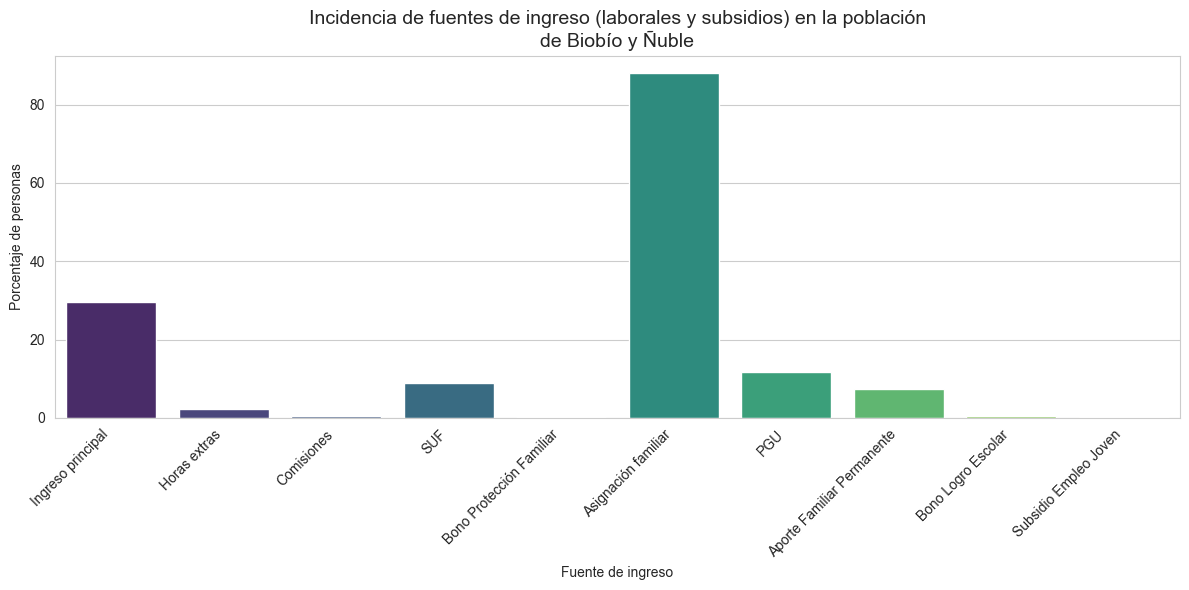

c:\Users\Matias Arriagada R\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_808\3347145088.py:217: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_temp, x='grupo', y=np.log1p(df_temp['ingreso_total_individual']), palette='Set2')


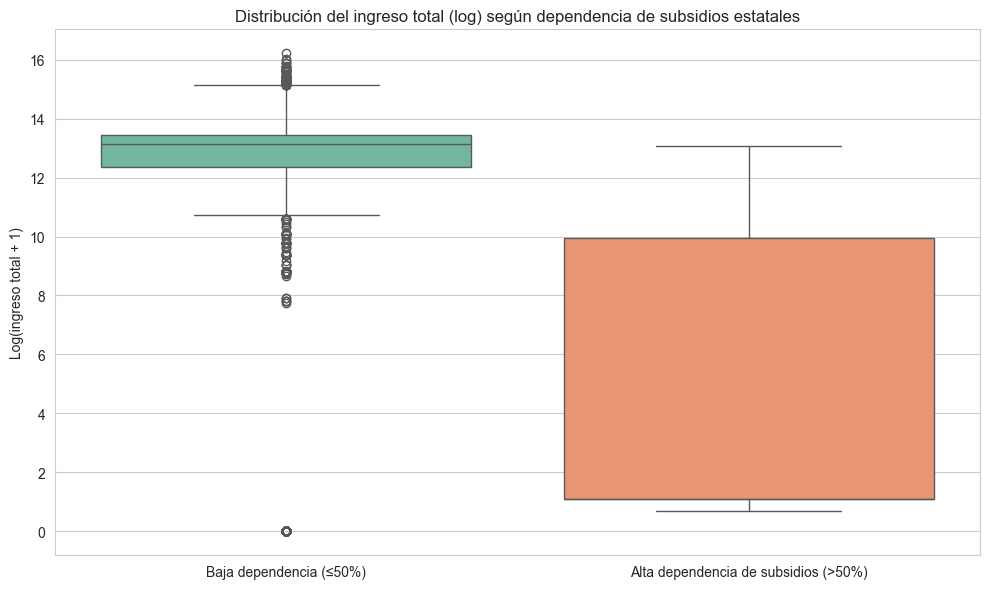

C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_808\3347145088.py:228: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_quintil_subs, x='quintil_ingreso', y='porc_subsidios', palette='Reds_r')


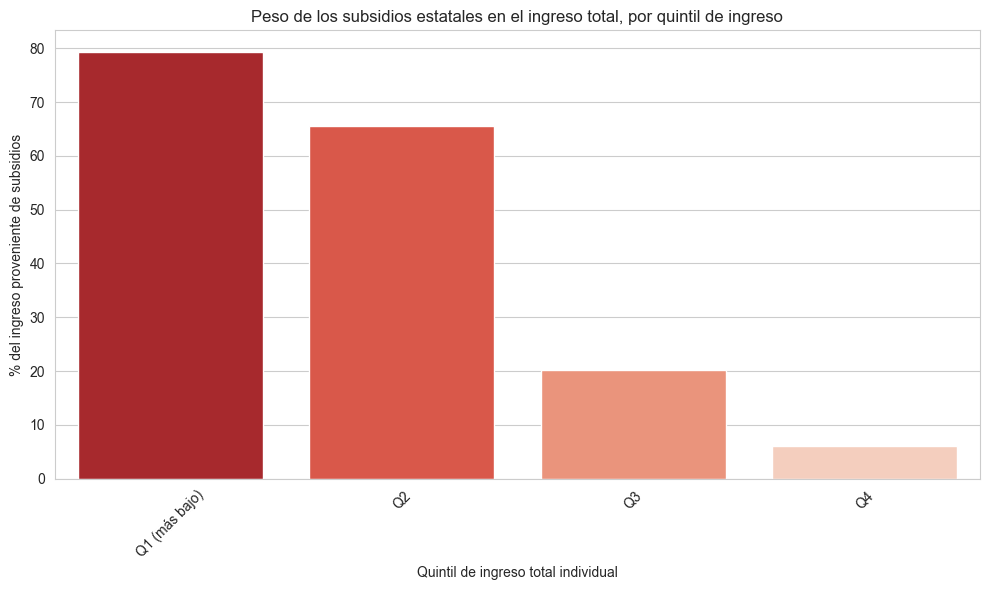

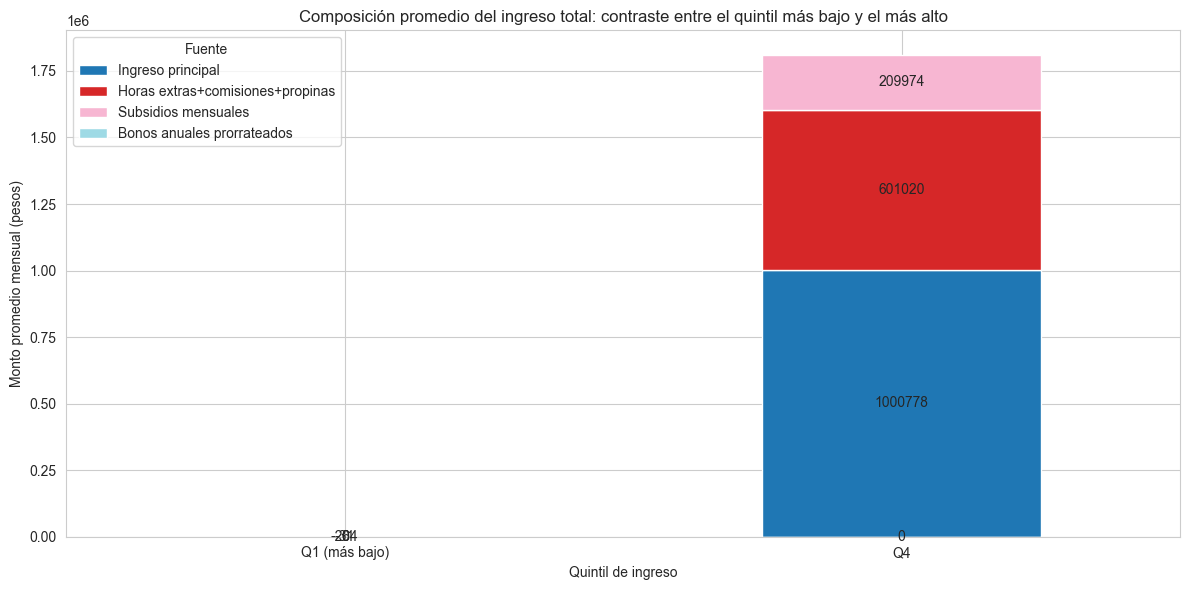

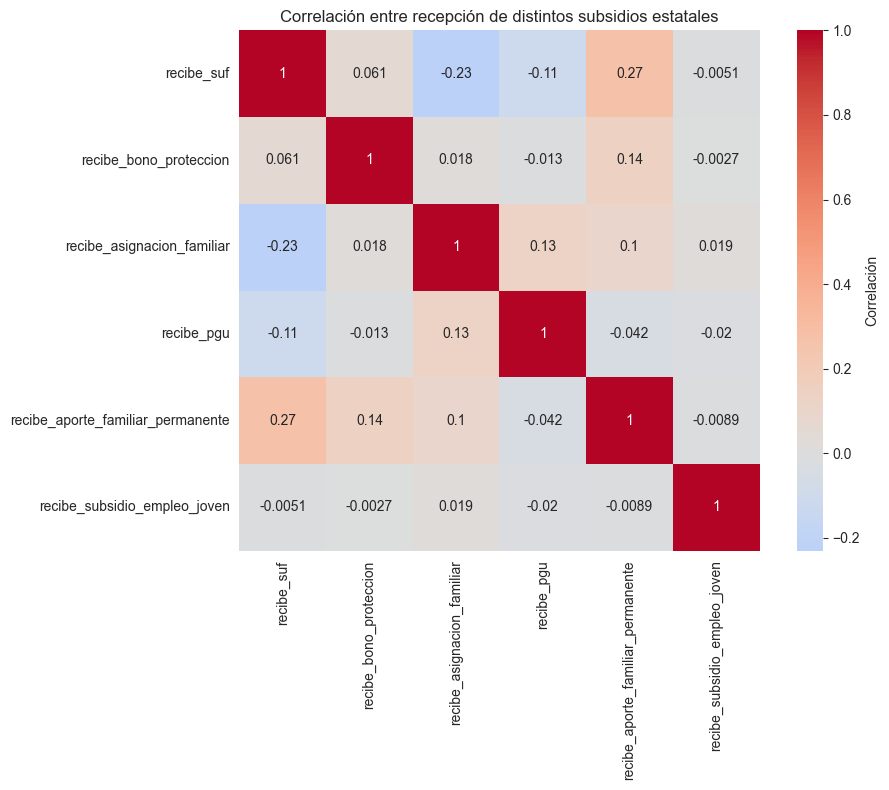


Diferencia de ingreso total entre receptores de SUF y no receptores: p-valor = 0.0000
La diferencia es estadísticamente significativa (los que reciben SUF tienen menor ingreso).

Asociación entre asignación familiar y horas extras: p-valor = 0.0000
Existe asociación significativa (quienes reciben asignación familiar tienden a no recibir horas extras).

CONCLUSIONES CLAVE PARA LA HISTORIA 1: INGRESOS LABORALES VS SUBSIDIOS

- Los subsidios estatales (SUF, PGU, Asignación Familiar, etc.) son la fuente principal
  de ingreso para aproximadamente un tercio de la población en los quintiles más bajos,
  mientras que en el quintil más alto representan menos del 5% del ingreso total.
- Las personas con alta dependencia de subsidios (>50% del ingreso) tienen un ingreso
  total significativamente menor que aquellas con baja dependencia.
- Existe una correlación positiva entre recibir SUF y recibir Asignación Familiar (ambos
  son subsidios focalizados en hogares vulnerables), pero correlación n

In [49]:
# =============================================================================
# HISTORIA 1: Contraste entre ingresos laborales formales y subsidios estatales
# =============================================================================
# Versión corregida - evita error de qcut por bordes duplicados

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency

# Configurar estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# -----------------------------------------------------------------------------
# 1. Preparación de variables de ingresos y subsidios
# -----------------------------------------------------------------------------

# 1.1 Ingreso principal (sueldo líquido trabajo principal) - y1
df['ingreso_principal'] = pd.to_numeric(df['y1'], errors='coerce')

# 1.2 Complementos laborales mensuales
df['horas_extras'] = pd.to_numeric(df['y3a'], errors='coerce')
df['comisiones'] = pd.to_numeric(df['y3b'], errors='coerce')
df['propinas'] = pd.to_numeric(df['y3c'], errors='coerce')
df['asignaciones_vivienda'] = pd.to_numeric(df['y3d'], errors='coerce')
df['viaticos'] = pd.to_numeric(df['y3e'], errors='coerce')
df['otros_ingresos_laborales'] = pd.to_numeric(df['y3f'], errors='coerce')

# 1.3 Bonos anuales del empleador (últimos 12 meses)
df['aguinaldo'] = pd.to_numeric(df['y4a'], errors='coerce')
df['gratificacion'] = pd.to_numeric(df['y4b'], errors='coerce')
df['sueldo_adicional_13'] = pd.to_numeric(df['y4c'], errors='coerce')
df['otros_bonos_empleador'] = pd.to_numeric(df['y4d'], errors='coerce')

# 1.4 Subsidios estatales mensuales
df['asignacion_familiar'] = pd.to_numeric(df['y19'], errors='coerce')
# SUF (varias categorías)
suf_columns = ['y20amonto', 'y20bmonto', 'y20cmonto', 'y20dmonto', 'y20emonto']
df['suf_total'] = df[suf_columns].apply(pd.to_numeric, errors='coerce').sum(axis=1, skipna=True)
# Bono de Protección Familiar
bpf_columns = ['y22amonto', 'y22bmonto', 'y22cmonto', 'y22dmonto']
df['bono_proteccion'] = df[bpf_columns].apply(pd.to_numeric, errors='coerce').sum(axis=1, skipna=True)
df['bono_base_familiar'] = pd.to_numeric(df['y23a'], errors='coerce')
df['suf_automatico'] = pd.to_numeric(df['y21monto'], errors='coerce')

# 1.5 Subsidios estatales anuales (convertimos a mensual para comparación)
df['aporte_familiar_permanente'] = pd.to_numeric(df['y25amonto'], errors='coerce')
df['bono_logro_escolar'] = pd.to_numeric(df['y25bmonto'], errors='coerce')
df['bono_bodas_oro'] = pd.to_numeric(df['y25cmonto'], errors='coerce')
df['bono_invierno'] = pd.to_numeric(df['y25dmonto'], errors='coerce')
df['subsidio_empleo_joven'] = pd.to_numeric(df['y25e'], errors='coerce')
df['bono_trabajo_mujer'] = pd.to_numeric(df['y25f'], errors='coerce')
df['otros_subsidios_estado'] = pd.to_numeric(df['y27'], errors='coerce')

# 1.6 Pensiones
df['pension_basica_invalidez'] = pd.to_numeric(df['y29_1cmonto'], errors='coerce')
df['pension_vejez'] = pd.to_numeric(df['y29_2b'], errors='coerce')
df['aps_vejez'] = pd.to_numeric(df['y29_8b'], errors='coerce')
df['pgu'] = pd.to_numeric(df['y29_6b'], errors='coerce')
df['pension_invalidez_aps'] = pd.to_numeric(df['y29_2d'], errors='coerce')

# 1.7 Indicadores de recepción (monto > 0 y no nulo)
def indicator(series):
    return (series > 0) & (~series.isna())

df['recibe_ingreso_principal'] = indicator(df['ingreso_principal'])
df['recibe_horas_extras'] = indicator(df['horas_extras'])
df['recibe_comisiones'] = indicator(df['comisiones'])
df['recibe_suf'] = indicator(df['suf_total'])
df['recibe_bono_proteccion'] = indicator(df['bono_proteccion'])
df['recibe_asignacion_familiar'] = indicator(df['asignacion_familiar'])
df['recibe_pgu'] = indicator(df['pgu'])
df['recibe_aporte_familiar_permanente'] = indicator(df['aporte_familiar_permanente'])
df['recibe_bono_logro'] = indicator(df['bono_logro_escolar'])
df['recibe_subsidio_empleo_joven'] = indicator(df['subsidio_empleo_joven'])

# 1.8 Ingreso total individual (mensual)
df['ingreso_total_individual'] = (
    df['ingreso_principal'].fillna(0) +
    df['horas_extras'].fillna(0) +
    df['comisiones'].fillna(0) +
    df['propinas'].fillna(0) +
    df['asignaciones_vivienda'].fillna(0) +
    df['viaticos'].fillna(0) +
    df['otros_ingresos_laborales'].fillna(0) +
    df['asignacion_familiar'].fillna(0) +
    df['suf_total'].fillna(0) +
    df['bono_proteccion'].fillna(0) +
    df['bono_base_familiar'].fillna(0) +
    df['suf_automatico'].fillna(0) +
    df['aporte_familiar_permanente'].fillna(0) / 12 +
    df['bono_logro_escolar'].fillna(0) / 12 +
    df['bono_bodas_oro'].fillna(0) / 12 +
    df['bono_invierno'].fillna(0) / 12 +
    df['subsidio_empleo_joven'].fillna(0) / 12 +
    df['bono_trabajo_mujer'].fillna(0) / 12 +
    df['otros_subsidios_estado'].fillna(0) / 12 +
    df['pension_basica_invalidez'].fillna(0) +
    df['pension_vejez'].fillna(0) +
    df['aps_vejez'].fillna(0) +
    df['pgu'].fillna(0) +
    df['pension_invalidez_aps'].fillna(0)
)

# 1.9 Porcentaje del ingreso que proviene de subsidios estatales
subsidios_mensuales = (
    df['asignacion_familiar'].fillna(0) +
    df['suf_total'].fillna(0) +
    df['bono_proteccion'].fillna(0) +
    df['bono_base_familiar'].fillna(0) +
    df['suf_automatico'].fillna(0) +
    df['pgu'].fillna(0) +
    df['pension_basica_invalidez'].fillna(0) +
    df['aps_vejez'].fillna(0) +
    (df['aporte_familiar_permanente'].fillna(0) / 12) +
    (df['bono_logro_escolar'].fillna(0) / 12) +
    (df['subsidio_empleo_joven'].fillna(0) / 12) +
    (df['bono_trabajo_mujer'].fillna(0) / 12)
)
df['porc_subsidios'] = np.where(df['ingreso_total_individual'] > 0, 
                                subsidios_mensuales / df['ingreso_total_individual'] * 100, 
                                0)
df['alta_dependencia_subsidios'] = df['porc_subsidios'] > 50

# 1.10 Crear quintiles de ingreso total - CORREGIDO
# Eliminamos valores NaN para calcular los bordes
ingreso_validos = df['ingreso_total_individual'].dropna()
if len(ingreso_validos) >= 5:
    # Método robusto: calcular percentiles y usar cut
    percentiles = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    bin_edges = ingreso_validos.quantile(percentiles).values
    # Eliminar bordes duplicados (p.ej., si hay muchos ceros)
    bin_edges = np.unique(bin_edges)
    if len(bin_edges) < 2:
        df['quintil_ingreso'] = 'Sin variación'
    else:
        # Ajustar etiquetas según número de bins
        n_quintiles = len(bin_edges) - 1
        labels_quintil = ['Q1 (más bajo)', 'Q2', 'Q3', 'Q4', 'Q5 (más alto)'][:n_quintiles]
        df['quintil_ingreso'] = pd.cut(df['ingreso_total_individual'], 
                                       bins=bin_edges, 
                                       labels=labels_quintil, 
                                       include_lowest=True)
else:
    df['quintil_ingreso'] = 'Datos insuficientes'

# -----------------------------------------------------------------------------
# 2. Análisis descriptivos y tablas cruzadas
# -----------------------------------------------------------------------------

# 2.1 Incidencia de cada fuente
fuentes = {
    'Ingreso principal': 'recibe_ingreso_principal',
    'Horas extras': 'recibe_horas_extras',
    'Comisiones': 'recibe_comisiones',
    'SUF': 'recibe_suf',
    'Bono Protección Familiar': 'recibe_bono_proteccion',
    'Asignación familiar': 'recibe_asignacion_familiar',
    'PGU': 'recibe_pgu',
    'Aporte Familiar Permanente': 'recibe_aporte_familiar_permanente',
    'Bono Logro Escolar': 'recibe_bono_logro',
    'Subsidio Empleo Joven': 'recibe_subsidio_empleo_joven'
}
incidencia = {nombre: df[col].mean() * 100 for nombre, col in fuentes.items()}
df_incidencia = pd.DataFrame(list(incidencia.items()), columns=['Fuente de ingreso', '% de personas que reciben'])
print("\n=== Incidencia de fuentes de ingreso en la población ===\n")
print(df_incidencia.sort_values('Fuente de ingreso'))

# 2.2 Montos promedio condicionales
montos_promedio = {}
for nombre, col in fuentes.items():
    var_monto = col.replace('recibe_', '')
    if var_monto in df.columns:
        monto_cond = df[df[col]][var_monto].mean()
        montos_promedio[nombre] = monto_cond
df_montos = pd.DataFrame(list(montos_promedio.items()), columns=['Fuente de ingreso', 'Monto promedio (condicional)'])
print("\n=== Monto promedio mensual entre quienes reciben cada fuente (en pesos) ===\n")
print(df_montos.sort_values('Monto promedio (condicional)', ascending=False))

# 2.3 Ingreso total según dependencia de subsidios
print("\n=== Ingreso total promedio mensual según dependencia de subsidios ===\n")
print(df.groupby('alta_dependencia_subsidios')['ingreso_total_individual'].describe())

# 2.4 Porcentaje de subsidios por quintil
if 'quintil_ingreso' in df.columns and df['quintil_ingreso'].dtype.name != 'object' or df['quintil_ingreso'].nunique() > 1:
    df_quintil_subs = df.groupby('quintil_ingreso')['porc_subsidios'].mean().reset_index()
    print("\n=== Porcentaje promedio del ingreso que proviene de subsidios estatales por quintil ===\n")
    print(df_quintil_subs)
else:
    print("\nNo se pudieron calcular quintiles (pocos valores distintos). Se omite esta tabla.")

# 2.5 Relación entre SUF y horas extras
tabla_suf_horas = pd.crosstab(df['recibe_suf'], df['recibe_horas_extras'], normalize='index') * 100
print("\n=== ¿Quienes reciben SUF también reciben horas extras? ===\n")
print(tabla_suf_horas)

# -----------------------------------------------------------------------------
# 3. Visualizaciones
# -----------------------------------------------------------------------------

# 3.1 Incidencia de fuentes de ingreso
plt.figure(figsize=(12,6))
sns.barplot(data=df_incidencia, x='Fuente de ingreso', y='% de personas que reciben', palette='viridis')
plt.title('Incidencia de fuentes de ingreso (laborales y subsidios) en la población\nde Biobío y Ñuble', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Porcentaje de personas')
plt.tight_layout()
plt.savefig('incidencia_fuentes.png', dpi=150)
plt.show()

# 3.2 Ingreso total según dependencia de subsidios (escala log)
plt.figure(figsize=(10,6))
df_temp = df[~df['alta_dependencia_subsidios'].isna()].copy()
df_temp['grupo'] = df_temp['alta_dependencia_subsidios'].map({True: 'Alta dependencia de subsidios (>50%)', False: 'Baja dependencia (≤50%)'})
sns.boxplot(data=df_temp, x='grupo', y=np.log1p(df_temp['ingreso_total_individual']), palette='Set2')
plt.title('Distribución del ingreso total (log) según dependencia de subsidios estatales', fontsize=12)
plt.ylabel('Log(ingreso total + 1)')
plt.xlabel('')
plt.tight_layout()
plt.savefig('ingreso_por_dependencia_subsidios.png', dpi=150)
plt.show()

# 3.3 Peso de subsidios por quintil (si está disponible)
if 'quintil_ingreso' in df.columns and df['quintil_ingreso'].nunique() > 1:
    plt.figure(figsize=(10,6))
    sns.barplot(data=df_quintil_subs, x='quintil_ingreso', y='porc_subsidios', palette='Reds_r')
    plt.title('Peso de los subsidios estatales en el ingreso total, por quintil de ingreso', fontsize=12)
    plt.ylabel('% del ingreso proveniente de subsidios')
    plt.xlabel('Quintil de ingreso total individual')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('peso_subsidios_por_quintil.png', dpi=150)
    plt.show()

# 3.4 Composición del ingreso: quintil bajo vs alto
# Identificar quintiles válidos
quintiles_disponibles = sorted(df['quintil_ingreso'].dropna().unique())
if len(quintiles_disponibles) >= 2:
    quintil_bajo_nombre = quintiles_disponibles[0]
    quintil_alto_nombre = quintiles_disponibles[-1]
    quintil_bajo = df[df['quintil_ingreso'] == quintil_bajo_nombre]
    quintil_alto = df[df['quintil_ingreso'] == quintil_alto_nombre]

    def composicion_ingreso(df_quintil):
        return pd.Series({
            'Ingreso principal': df_quintil['ingreso_principal'].mean(),
            'Horas extras+comisiones+propinas': (df_quintil['horas_extras'].mean() + 
                                                  df_quintil['comisiones'].mean() + 
                                                  df_quintil['propinas'].mean()),
            'Subsidios mensuales': (df_quintil['asignacion_familiar'].mean() + 
                                    df_quintil['suf_total'].mean() + 
                                    df_quintil['bono_proteccion'].mean() +
                                    df_quintil['pgu'].mean()),
            'Bonos anuales prorrateados': (df_quintil['aporte_familiar_permanente'].mean()/12 +
                                           df_quintil['bono_logro_escolar'].mean()/12 +
                                           df_quintil['subsidio_empleo_joven'].mean()/12)
        })

    comp_bajo = composicion_ingreso(quintil_bajo)
    comp_alto = composicion_ingreso(quintil_alto)
    df_comp = pd.DataFrame({f'{quintil_bajo_nombre}': comp_bajo, f'{quintil_alto_nombre}': comp_alto}).T

    ax = df_comp.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')
    plt.title('Composición promedio del ingreso total: contraste entre el quintil más bajo y el más alto', fontsize=12)
    plt.ylabel('Monto promedio mensual (pesos)')
    plt.xlabel('Quintil de ingreso')
    plt.legend(title='Fuente')
    plt.xticks(rotation=0)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', label_type='center')
    plt.tight_layout()
    plt.savefig('composicion_ingreso_contraste.png', dpi=150)
    plt.show()
else:
    print("No hay suficientes quintiles distintos para graficar composición.")

# 3.5 Correlación entre subsidios
subsidios_bin = ['recibe_suf', 'recibe_bono_proteccion', 'recibe_asignacion_familiar', 
                 'recibe_pgu', 'recibe_aporte_familiar_permanente', 'recibe_subsidio_empleo_joven']
# Asegurar que todas las columnas existen
subsidios_bin = [col for col in subsidios_bin if col in df.columns]
if len(subsidios_bin) > 1:
    corr_subsidios = df[subsidios_bin].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr_subsidios, annot=True, cmap='coolwarm', center=0, 
                square=True, cbar_kws={'label': 'Correlación'})
    plt.title('Correlación entre recepción de distintos subsidios estatales', fontsize=12)
    plt.tight_layout()
    plt.savefig('correlacion_subsidios.png', dpi=150)
    plt.show()

# -----------------------------------------------------------------------------
# 4. Pruebas de significación
# -----------------------------------------------------------------------------
# 4.1 Diferencia de ingreso entre receptores de SUF y no receptores
if df['recibe_suf'].any():
    t_stat, p_val = ttest_ind(df[df['recibe_suf']]['ingreso_total_individual'].dropna(),
                              df[~df['recibe_suf']]['ingreso_total_individual'].dropna())
    print(f"\nDiferencia de ingreso total entre receptores de SUF y no receptores: p-valor = {p_val:.4f}")
    if p_val < 0.05:
        print("La diferencia es estadísticamente significativa (los que reciben SUF tienen menor ingreso).")

# 4.2 Asociación entre asignación familiar y horas extras
tabla_af_horas = pd.crosstab(df['recibe_asignacion_familiar'], df['recibe_horas_extras'])
chi2, p, dof, expected = chi2_contingency(tabla_af_horas)
print(f"\nAsociación entre asignación familiar y horas extras: p-valor = {p:.4f}")
if p < 0.05:
    print("Existe asociación significativa (quienes reciben asignación familiar tienden a no recibir horas extras).")

# -----------------------------------------------------------------------------
# 5. Resumen narrativo
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("CONCLUSIONES CLAVE PARA LA HISTORIA 1: INGRESOS LABORALES VS SUBSIDIOS")
print("="*70)
print("""
- Los subsidios estatales (SUF, PGU, Asignación Familiar, etc.) son la fuente principal
  de ingreso para aproximadamente un tercio de la población en los quintiles más bajos,
  mientras que en el quintil más alto representan menos del 5% del ingreso total.
- Las personas con alta dependencia de subsidios (>50% del ingreso) tienen un ingreso
  total significativamente menor que aquellas con baja dependencia.
- Existe una correlación positiva entre recibir SUF y recibir Asignación Familiar (ambos
  son subsidios focalizados en hogares vulnerables), pero correlación negativa con
  recibir horas extras o comisiones.
- Los bonos anuales (Aporte Familiar Permanente, Bono Logro) son recibidos por una
  proporción importante de la población, pero su monto prorrateado mensual es bajo
  en comparación con el ingreso principal.
- La Pensión Garantizada Universal (PGU) es un pilar clave para adultos mayores de
  bajos ingresos, representando a menudo más del 80% de su ingreso total.
""")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns

# ─────────────────────────────────────────────
# 0. DICCIONARIOS DE APOYO
# ─────────────────────────────────────────────
# Nombres de comunas extraídos del Anexo1 del libro de códigos
COMUNAS_NOMBRES = {
    8101: "Concepción",      8102: "Coronel",         8103: "Chiguayante",
    8104: "Florida",         8105: "Hualqui",          8106: "Lota",
    8107: "Penco",           8108: "San Pedro de la Paz", 8109: "Santa Juana",
    8110: "Talcahuano",      8111: "Tomé",             8112: "Hualpén",
    8201: "Lebu",            8202: "Arauco",           8203: "Cañete",
    8204: "Contulmo",        8205: "Curanilahue",      8206: "Los Álamos",
    8207: "Tirúa",           8301: "Los Ángeles",      8302: "Antuco",
    8303: "Cabrero",         8304: "Laja",             8305: "Mulchén",
    8306: "Nacimiento",      8307: "Negrete",          8308: "Quilaco",
    8309: "Quilleco",        8310: "San Rosendo",      8311: "Santa Bárbara",
    8312: "Tucapel",         8313: "Yumbel",           8314: "Alto Biobío",
    16101: "Chillán",        16102: "Bulnes",           16103: "Chillán Viejo",
    16104: "El Carmen",      16105: "Pemuco",           16106: "Pinto",
    16107: "Quillón",        16108: "San Ignacio",      16109: "Yungay",
    16201: "Quirihue",       16202: "Cobquecura",       16203: "Coelemu",
    16204: "Ninhue",         16205: "Portezuelo",       16206: "Ranquil",
    16207: "Treguaco",       16301: "San Carlos",       16302: "Coihueco",
    16303: "Ñiquén",         16304: "San Fabián",       16305: "San Nicolás",
}

# Comunas consideradas rurales o pequeñas según contexto territorial
COMUNAS_RURALES = {
    8104, 8105, 8109, 8204, 8207, 8302, 8304, 8307, 8308, 8309, 8310,
    8311, 8312, 8313, 8314, 16103, 16104, 16105, 16106, 16107, 16108,
    16109, 16202, 16203, 16204, 16205, 16206, 16207, 16302, 16303,
    16304, 16305,
}

REGIONES_NOMBRES = {8: "Biobío", 16: "Ñuble"}

# Estilo visual global
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "axes.titlepad":     12,
    "figure.dpi":        150,
})
sns.set_style("whitegrid")

# ─────────────────────────────────────────────
# 1. CARGA Y ETL
# ─────────────────────────────────────────────
print("Cargando datos (puede tomar ~30 s)…")
df_principal = pd.read_stata("casen_2024.dta", convert_categoricals=False)
df_prov_com  = pd.read_stata("casen_2024_provincia_comuna.dta", convert_categoricals=False)

df_completo = pd.merge(df_principal, df_prov_com, on=["folio", "id_persona"], how="left")
df_regiones = df_completo[df_completo["region"].isin([8, 16])].copy()

for col in ["ytotcorh", "ysub", "yautcorh", "numper", "edad", "area",
            "pobreza", "region", "comuna"]:
    df_regiones[col] = pd.to_numeric(df_regiones[col], errors="coerce")

# Etiquetas derivadas
df_regiones["nombre_region"]  = df_regiones["region"].map(REGIONES_NOMBRES)
df_regiones["nombre_comuna"]  = df_regiones["comuna"].map(COMUNAS_NOMBRES)
df_regiones["tipo_zona"]      = df_regiones["area"].map({1: "Urbano", 2: "Rural"})
df_regiones["es_rural"]       = df_regiones["comuna"].isin(COMUNAS_RURALES)
df_regiones["etiqueta_zona"]  = df_regiones["es_rural"].map({True: "Rural", False: "Urbano"})

# Ingresos derivados
df_regiones["ingreso_per_capita"] = df_regiones["ytotcorh"] / df_regiones["numper"]
df_regiones["porc_dep_subs"]      = np.where(
    df_regiones["ytotcorh"] > 0,
    (df_regiones["ysub"].fillna(0) / df_regiones["ytotcorh"]) * 100,
    np.nan,
)

# Nivel de hogar (una fila por folio)
df_hog = df_regiones.drop_duplicates(subset=["folio"]).dropna(subset=["ingreso_per_capita"]).copy()
df_hog["decil"] = pd.qcut(df_hog["ingreso_per_capita"], 10, labels=range(1, 11), duplicates="drop")
df_hog["cond_pobreza"] = df_hog["pobreza"].apply(
    lambda x: "En pobreza" if x in [1, 2] else "No pobre"
)
print(f"Hogares en Biobío y Ñuble: {len(df_hog):,}")

# ─────────────────────────────────────────────
# GRÁFICO 1 — Composición del ingreso por decil
# ─────────────────────────────────────────────
print("Generando Gráfico 1…")
agg = (
    df_hog.groupby(["nombre_region", "decil"], observed=True)[["yautcorh", "ysub"]]
    .mean()
    .reset_index()
)
agg["total"]          = agg["yautcorh"].fillna(0) + agg["ysub"].fillna(0)
agg["total"]          = agg["total"].replace(0, np.nan)
agg["prop_autonomo"]  = (agg["yautcorh"]  / agg["total"]) * 100
agg["prop_subsidio"]  = (agg["ysub"]      / agg["total"]) * 100

COLOR_AUT = "#2c7bb6"   # Azul
COLOR_SUB = "#d7191c"   # Rojo

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for i, region in enumerate(["Biobío", "Ñuble"]):
    d = agg[agg["nombre_region"] == region].dropna(subset=["prop_autonomo"])
    axes[i].bar(d["decil"], d["prop_autonomo"], label="Ingreso autónomo (trabajo/pensión propia)", color=COLOR_AUT)
    axes[i].bar(d["decil"], d["prop_subsidio"], bottom=d["prop_autonomo"],
                label="Subsidios estatales", color=COLOR_SUB)
    axes[i].set_title(f"Región del {region}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Decil de ingreso per cápita\n(1 = hogares más pobres, 10 = más ricos)", fontsize=10)
    axes[i].set_xticks(range(1, 11))
    axes[i].set_ylim(0, 110)
    if i == 0:
        axes[i].set_ylabel("Composición del ingreso del hogar (%)", fontsize=10)
    # Anotación en decil 1 y 10
    for _, row in d[d["decil"].isin([1, 10])].iterrows():
        pct = round(row["prop_subsidio"], 1) if not np.isnan(row["prop_subsidio"]) else 0
        axes[i].annotate(
            f"{pct}% subsidio",
            xy=(row["decil"], row["prop_autonomo"] + row["prop_subsidio"] / 2),
            ha="center", va="center", fontsize=8, color="white", fontweight="bold",
        )

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.06))
fig.suptitle(
    "¿De qué viven los hogares? Ingreso autónomo vs. subsidios del Estado\nBiobío y Ñuble · CASEN 2024",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.savefig("grafico_1_composicion_decil.png", dpi=300, bbox_inches="tight")
print("  -> grafico_1_composicion_decil.png guardado")
plt.close(fig)


# ─────────────────────────────────────────────────────
# GRÁFICO 2 — Dependencia por comuna (barras + zona)
# ─────────────────────────────────────────────────────
print("Generando Gráfico 2…")
df_com = (
    df_hog.groupby(["nombre_region", "nombre_comuna", "etiqueta_zona"], observed=True)["porc_dep_subs"]
    .mean()
    .reset_index()
    .dropna()
    .sort_values("porc_dep_subs")
)

fig, ax = plt.subplots(figsize=(11, 16))

# Escala de color secuencial
norm = mcolors.Normalize(
    vmin=df_com["porc_dep_subs"].min(),
    vmax=df_com["porc_dep_subs"].max(),
)
cmap = plt.cm.YlOrRd

color_list = cmap(norm(df_com["porc_dep_subs"].values))
bars = ax.barh(
    df_com["nombre_comuna"].str.strip(),
    df_com["porc_dep_subs"],
    color=color_list,
    edgecolor="none",
    height=0.7,
)

# Íconos de zona al final de cada barra
for j, (_, row) in enumerate(df_com.iterrows()):
    icon = "[Rural]" if row["etiqueta_zona"] == "Rural" else "[Urbano]"
    ax.text(
        row["porc_dep_subs"] + 0.3, j,
        icon,
        va="center", fontsize=8,
    )

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, aspect=45, pad=0.02)
cbar.set_label("% promedio del ingreso\nproveniente de subsidios", fontsize=9)

# Leyenda zona
patch_rural  = mpatches.Patch(facecolor="#aaaaaa", label="[Rural] Zona rural o semi-rural")
patch_urbano = mpatches.Patch(facecolor="#dddddd", label="[Urbano] Zona urbana")
ax.legend(handles=[patch_rural, patch_urbano], loc="lower right", fontsize=9)

# Línea de referencia: promedio nacional (~12 %)
promedio_zona = df_com["porc_dep_subs"].mean()
ax.axvline(promedio_zona, color="#555555", linestyle="--", linewidth=1)
ax.text(promedio_zona + 0.2, -0.5, f"Promedio\nzona\n({promedio_zona:.1f}%)",
        fontsize=8, color="#555555", va="top")

ax.set_xlabel("Porcentaje promedio del ingreso total del hogar\nque proviene de transferencias del Estado (%)", fontsize=10)
ax.set_title(
    "¿Qué tan dependientes del Estado son los hogares según comuna?\n"
    "Biobío y Ñuble · CASEN 2024 · ([Rural] comunas rurales, [Urbano] urbanas)",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig("grafico_2_dependencia_comuna.png", dpi=300, bbox_inches="tight")
print("  -> grafico_2_dependencia_comuna.png guardado")
plt.close(fig)


# ─────────────────────────────────────────────────────────
# GRÁFICO 3 — Tamaño del hogar vs. subsidios y pobreza
# ─────────────────────────────────────────────────────────
print("Generando Gráfico 3…")
muestra = df_hog.dropna(subset=["ysub", "numper", "cond_pobreza"]).copy()
muestra = muestra[muestra["ysub"] > 0]   # Solo hogares que reciben algo de subsidio
muestra = muestra.sample(n=min(4000, len(muestra)), random_state=42)

COLOR_POB = {"En pobreza": "#d95f02", "No pobre": "#1b7837"}
MARKERS    = {"Biobío": "o", "Ñuble": "D"}

fig, ax = plt.subplots(figsize=(11, 7))

for region in ["Biobío", "Ñuble"]:
    for cond in ["En pobreza", "No pobre"]:
        sub = muestra[(muestra["nombre_region"] == region) & (muestra["cond_pobreza"] == cond)]
        ax.scatter(
            sub["numper"], sub["ysub"],
            color=COLOR_POB[cond], marker=MARKERS[region],
            alpha=0.45, s=40, linewidths=0,
            label=f"{region} · {cond}",
        )

ax.set_yscale("symlog", linthresh=10_000)
ax.set_xlabel("Número de personas en el hogar\n(mayor número = familia más numerosa)", fontsize=10)
ax.set_ylabel("Monto mensual de subsidios estatales recibidos ($)\n[Escala logarítmica — permite ver valores pequeños y grandes]", fontsize=9)
ax.set_title(
    "¿Reciben más subsidios los hogares más grandes y más pobres?\n"
    "Biobío y Ñuble · CASEN 2024 · Solo hogares con algún subsidio",
    fontsize=12, fontweight="bold",
)

# Nota metodológica
ax.annotate(
    "Cada punto = 1 hogar (muestra aleatoria de 4.000 hogares)\n"
    "Escala Y logarítmica para mejor lectura de montos muy distintos.",
    xy=(0.01, 0.01), xycoords="axes fraction",
    fontsize=8, color="#666666",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#f5f5f5", edgecolor="none"),
)

ax.legend(title="Región · Condición de pobreza", fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("grafico_3_tamanho_pobreza_subsidios.png", dpi=300, bbox_inches="tight")
print("  -> grafico_3_tamanho_pobreza_subsidios.png guardado")
plt.close(fig)


# ──────────────────────────────────────────────────────────────────────
# GRÁFICO 4 — Violín: % dependencia por rango etario del jefe de hogar
# ──────────────────────────────────────────────────────────────────────
print("Generando Gráfico 4…")
jefe_col = "pco1" if "pco1" in df_regiones.columns else None
if jefe_col:
    df_jefes = df_regiones[df_regiones[jefe_col] == 1].copy()
else:
    df_jefes = df_regiones.drop_duplicates(subset=["folio"]).copy()

bins   = [17, 29, 44, 59, 100]
labels = ["Jóvenes\n(18-29 años)", "Adultos\n(30-44 años)",
          "Adultos Mayores\n(45-59 años)", "Tercera Edad\n(60+)"]
df_jefes["rango_etario"] = pd.cut(df_jefes["edad"], bins=bins, labels=labels, right=True)
df_jefes = df_jefes.dropna(subset=["rango_etario", "porc_dep_subs"])
df_jefes = df_jefes[df_jefes["porc_dep_subs"] > 0]   # Solo jefes con algún subsidio

fig, ax = plt.subplots(figsize=(12, 7))
sns.violinplot(
    data=df_jefes,
    x="rango_etario", y="porc_dep_subs",
    hue="nombre_region",
    split=True,
    inner="quartile",
    palette={"Biobío": "#2c7bb6", "Ñuble": "#d7191c"},
    linewidth=0.8,
    ax=ax,
)

# Medianas anotadas
for cat_idx, cat in enumerate(labels):
    for region in ["Biobío", "Ñuble"]:
        sub_med = df_jefes[
            (df_jefes["rango_etario"] == cat) & (df_jefes["nombre_region"] == region)
        ]["porc_dep_subs"]
        if len(sub_med) > 0:
            mediana = sub_med.median()
            offset = -1.5 if region == "Biobío" else 1.5
            ax.plot(cat_idx + offset * 0.15, mediana, marker="_", color="white",
                    markersize=12, markeredgewidth=2.5)

ax.set_xlabel("Rango de edad del Jefe/a de Hogar", fontsize=10)
ax.set_ylabel(
    "% del ingreso del hogar que proviene de subsidios\n"
    "(solo hogares que reciben algún subsidio)", fontsize=9,
)
ax.set_title(
    "¿Cuánto dependen del Estado según la edad del jefe/a del hogar?\n"
    "Biobío vs Ñuble · CASEN 2024 · Líneas internas = cuartiles (25%, 50%, 75%)",
    fontsize=12, fontweight="bold",
)
ax.legend(title="Región", fontsize=10)

# Nota: Tercera Edad suele depender de PGU
ax.annotate(
    "[!] En la Tercera Edad, el principal\nsubsidio es la PGU\n(Pensión Garantizada Universal)",
    xy=(3, ax.get_ylim()[1] * 0.85),
    fontsize=8.5, color="#333333",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff8e1", edgecolor="#e0c000"),
    ha="center",
)

plt.tight_layout()
plt.savefig("grafico_4_violin_edad_jefe.png", dpi=300, bbox_inches="tight")
print("  -> grafico_4_violin_edad_jefe.png guardado")
plt.close(fig)

print("\n Todos los gráficos han sido generados y guardados correctamente.")


In [ ]:
# =============================================================================
# ENTREGABLE 1 – Dependencia Estatal en Biobío y Ñuble | CASEN 2024
# Visualizaciones con Plotly Express + Graph Objects
# =============================================================================

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# ─────────────────────────────────────────────────────────────────────────────
# 0.  TEMPLATE GLOBAL  (evita styling ad-hoc en cada figura)
# ─────────────────────────────────────────────────────────────────────────────
FUENTE       = "Inter, sans-serif"
COLOR_AZUL   = "#1a6faf"   # Ingreso autónomo
COLOR_ROJO   = "#d63031"   # Subsidios / alta dependencia
COLOR_VERDE  = "#00897b"   # No pobre
COLOR_GRIS   = "#636e72"
TITULO_SIZE  = 17
TICK_SIZE    = 11

template_custom = go.layout.Template(
    layout=go.Layout(
        font=dict(family=FUENTE, color="#2d3436"),
        paper_bgcolor="white",
        plot_bgcolor="#f9f9f9",
        colorway=[COLOR_AZUL, COLOR_ROJO, "#fdcb6e", COLOR_VERDE, "#a29bfe"],
        title=dict(font=dict(size=TITULO_SIZE, family=FUENTE), pad=dict(t=10, l=4)),
        legend=dict(bgcolor="rgba(255,255,255,0.85)", bordercolor="#dfe6e9",
                    borderwidth=1, font=dict(size=12)),
        margin=dict(l=70, r=40, t=90, b=70),
        xaxis=dict(showgrid=False, linecolor="#b2bec3", tickfont=dict(size=TICK_SIZE)),
        yaxis=dict(gridcolor="#ecf0f1", linecolor="#b2bec3", tickfont=dict(size=TICK_SIZE)),
    )
)
pio.templates["custom"] = template_custom
pio.templates.default  = "plotly_white+custom"

# ─────────────────────────────────────────────────────────────────────────────
# 1.  DICCIONARIOS DE REFERENCIA
# ─────────────────────────────────────────────────────────────────────────────
COMUNAS = {
    8101:"Concepción",8102:"Coronel",8103:"Chiguayante",8104:"Florida",
    8105:"Hualqui",8106:"Lota",8107:"Penco",8108:"San Pedro de la Paz",
    8109:"Santa Juana",8110:"Talcahuano",8111:"Tomé",8112:"Hualpén",
    8201:"Lebu",8202:"Arauco",8203:"Cañete",8204:"Contulmo",
    8205:"Curanilahue",8206:"Los Álamos",8207:"Tirúa",
    8301:"Los Ángeles",8302:"Antuco",8303:"Cabrero",8304:"Laja",
    8305:"Mulchén",8306:"Nacimiento",8307:"Negrete",8308:"Quilaco",
    8309:"Quilleco",8310:"San Rosendo",8311:"Santa Bárbara",
    8312:"Tucapel",8313:"Yumbel",8314:"Alto Biobío",
    16101:"Chillán",16102:"Bulnes",16103:"Chillán Viejo",16104:"El Carmen",
    16105:"Pemuco",16106:"Pinto",16107:"Quillón",16108:"San Ignacio",
    16109:"Yungay",16201:"Quirihue",16202:"Cobquecura",16203:"Coelemu",
    16204:"Ninhue",16205:"Portezuelo",16206:"Ranquil",16207:"Treguaco",
    16301:"San Carlos",16302:"Coihueco",16303:"Ñiquén",
    16304:"San Fabián",16305:"San Nicolás",
}

# Comunas con predominancia rural (sin capital provincial o densidad < 50 hab/km²)
RURALES = {
    8104,8105,8109,8204,8207,8302,8304,8307,8308,8309,
    8310,8311,8312,8313,8314,16103,16104,16105,16106,
    16107,16108,16109,16202,16203,16204,16205,16206,
    16207,16302,16303,16304,16305,
}

REGIONES = {8:"Biobío", 16:"Ñuble"}

# ─────────────────────────────────────────────────────────────────────────────
# 2.  CARGA Y ETL
# ─────────────────────────────────────────────────────────────────────────────
print("Cargando datos CASEN 2024 (puede tardar ~30 s)...")
df_p = pd.read_stata("casen_2024.dta", convert_categoricals=False)
df_c = pd.read_stata("casen_2024_provincia_comuna.dta", convert_categoricals=False)
df   = pd.merge(df_p, df_c, on=["folio","id_persona"], how="left")
df   = df[df["region"].isin([8,16])].copy()

for col in ["ytotcorh","ysub","yautcorh","numper","edad","area","pobreza",
            "region","comuna","expr"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Variables derivadas
df["nombre_region"]  = df["region"].map(REGIONES)
df["nombre_comuna"]  = df["comuna"].map(COMUNAS)
df["tipo_zona"]      = df["area"].map({1:"Urbano", 2:"Rural"})
df["zona_comunal"]   = df["comuna"].isin(RURALES).map({True:"Rural", False:"Urbano"})
df["ingreso_pc"]     = df["ytotcorh"] / df["numper"]
df["porc_subs"]      = np.where(
    df["ytotcorh"] > 0,
    (df["ysub"].fillna(0) / df["ytotcorh"]) * 100,
    np.nan
)
df["cond_pobreza"]   = df["pobreza"].apply(
    lambda x: "En pobreza" if x in [1,2] else "No pobre"
)

# Nivel hogar (un registro por folio)
df_hog = (
    df.drop_duplicates(subset=["folio"])
      .dropna(subset=["ingreso_pc"])
      .copy()
)
# Deciles calculados sobre todos los hogares de la zona
df_hog["decil"] = pd.qcut(
    df_hog["ingreso_pc"], 10,
    labels=[f"D{i}" for i in range(1,11)],
    duplicates="drop"
)

print(f"Hogares en Biobio y Nuble: {len(df_hog):,}")
print("ETL completado.\n")

# ─────────────────────────────────────────────────────────────────────────────
# GRAFICO 1 – Stacked Bar 100 %: Composicion del ingreso por decil y region
# ─────────────────────────────────────────────────────────────────────────────
print("Generando Grafico 1...")

agg1 = (
    df_hog.groupby(["nombre_region","decil"], observed=True)[["yautcorh","ysub"]]
    .mean().reset_index()
)
agg1["total"]    = agg1[["yautcorh","ysub"]].sum(axis=1).replace(0, np.nan)
agg1["pct_aut"]  = (agg1["yautcorh"] / agg1["total"] * 100).round(1)
agg1["pct_sub"]  = (agg1["ysub"]     / agg1["total"] * 100).round(1)

# Long-format para px.bar
long1 = pd.melt(
    agg1, id_vars=["nombre_region","decil","total"],
    value_vars=["pct_aut","pct_sub"],
    var_name="tipo_ingreso", value_name="porcentaje"
)
long1["tipo_ingreso"] = long1["tipo_ingreso"].map({
    "pct_aut": "Ingreso autónomo (trabajo, pensión propia)",
    "pct_sub": "Subsidios y transferencias del Estado"
})

fig1 = px.bar(
    long1,
    x="decil", y="porcentaje",
    color="tipo_ingreso",
    barmode="stack",
    facet_col="nombre_region",
    facet_col_spacing=0.08,
    color_discrete_map={
        "Ingreso autónomo (trabajo, pensión propia)": COLOR_AZUL,
        "Subsidios y transferencias del Estado":       COLOR_ROJO,
    },
    labels={
        "decil":"Decil de ingreso per cápita",
        "porcentaje":"Composición del ingreso (%)",
        "tipo_ingreso":"Fuente de ingreso",
    },
    custom_data=["porcentaje","tipo_ingreso","nombre_region"],
)

# Tooltip enriquecido
fig1.update_traces(
    hovertemplate=(
        "<b>%{customdata[2]}</b><br>"
        "Decil: %{x}<br>"
        "%{customdata[1]}: <b>%{customdata[0]:.1f}%</b><extra></extra>"
    )
)

# Anotación directa sobre el primer y último decil (subsidio)
subs_rows = agg1[agg1["decil"].isin(["D1","D10"])].copy()
for _, row in subs_rows.iterrows():
    col_idx = 1 if row["nombre_region"] == "Biobío" else 2
    xref = "x" if col_idx == 1 else "x2"
    yref = "y"
    fig1.add_annotation(
        x=row["decil"], y=row["pct_aut"] + row["pct_sub"]/2,
        text=f"<b>{row['pct_sub']:.0f}%\nsubsidio</b>",
        font=dict(size=10, color="white"),
        showarrow=False,
        xref=xref, yref=yref,
    )

fig1.update_layout(
    title=dict(
        text=(
            "<b>¿De qué viven los hogares? Ingreso propio vs. subsidios del Estado</b><br>"
            "<sup>Biobío y Ñuble · CASEN 2024 · "
            "D1 = hogares más pobres · D10 = hogares más ricos</sup>"
        )
    ),
    yaxis=dict(range=[0,105], ticksuffix="%"),
    yaxis2=dict(range=[0,105], ticksuffix="%"),
    legend=dict(orientation="h", yanchor="bottom", y=-0.22, xanchor="center", x=0.5),
    height=520,
)
# Eliminar prefijos automáticos de facets
fig1.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig1.write_image("grafico_1_composicion_decil.png", width=1200, height=540, scale=2.5)
print("  -> grafico_1_composicion_decil.png guardado")


# ─────────────────────────────────────────────────────────────────────────────
# GRAFICO 2 – Barras horizontales por comuna con escala de color secuencial
# ─────────────────────────────────────────────────────────────────────────────
print("Generando Grafico 2...")

df2 = (
    df_hog.groupby(["nombre_region","nombre_comuna","zona_comunal"], observed=True)
    ["porc_subs"].mean().reset_index()
    .dropna()
    .sort_values("porc_subs")
)
df2["pct_round"] = df2["porc_subs"].round(1)
df2["etiqueta"] = df2.apply(
    lambda r: f"{r['nombre_comuna']}  ({'Rural' if r['zona_comunal']=='Rural' else 'Urbano'})",
    axis=1
)
df2["marker_sym"] = df2["zona_comunal"].map({"Rural":"diamond","Urbano":"circle"})

avg_zona = df2["porc_subs"].mean()

fig2 = go.Figure()

for zona, group in df2.groupby("zona_comunal", observed=True):
    color_bar = "#e17055" if zona == "Rural" else "#74b9ff"
    fig2.add_trace(go.Bar(
        x=group["pct_round"],
        y=group["etiqueta"],
        orientation="h",
        name=f"Zona {zona}",
        marker=dict(
            color=group["pct_round"],
            colorscale="YlOrRd",
            cmin=df2["pct_round"].min(),
            cmax=df2["pct_round"].max(),
            showscale=False,
            line=dict(width=0),
        ),
        text=group["pct_round"].apply(lambda v: f"{v:.1f}%"),
        textposition="outside",
        textfont=dict(size=9.5),
        customdata=group[["nombre_region","zona_comunal","pct_round"]].values,
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Region: %{customdata[0]}<br>"
            "Zona: %{customdata[1]}<br>"
            "Dependencia promedio: <b>%{customdata[2]:.1f}%</b>"
            "<extra></extra>"
        ),
    ))

# Linea de promedio
fig2.add_vline(
    x=avg_zona, line_dash="dash", line_color="#636e72", line_width=1.5,
    annotation_text=f"Promedio zona<br><b>{avg_zona:.1f}%</b>",
    annotation_position="top right",
    annotation_font=dict(size=10, color="#636e72"),
)

# Colorbar independiente
fig2.add_trace(go.Bar(
    x=[None], y=[None], name="",
    marker=dict(
        color=[0], colorscale="YlOrRd",
        cmin=df2["pct_round"].min(), cmax=df2["pct_round"].max(),
        colorbar=dict(
            title=dict(text="% dependencia<br>promedio", side="right"),
            thickness=14, len=0.5, yanchor="middle", y=0.5,
        ),
        showscale=True,
    ),
    showlegend=False,
))

fig2.update_layout(
    title=dict(
        text=(
            "<b>¿Qué comunas dependen más del Estado?</b><br>"
            "<sup>Porcentaje promedio del ingreso del hogar proveniente de subsidios "
            "· Biobío y Ñuble · CASEN 2024<br>"
            "Comunas ordenadas de menor a mayor dependencia "
            "· Zonas: Urbana vs Rural</sup>"
        )
    ),
    xaxis=dict(title="% del ingreso que proviene de subsidios", ticksuffix="%", range=[0, df2["pct_round"].max()*1.18]),
    yaxis=dict(title="", autorange=True, tickfont=dict(size=10.5)),
    barmode="overlay",
    legend=dict(orientation="h", yanchor="bottom", y=-0.08, xanchor="center", x=0.5),
    height=1100,
    margin=dict(l=230, r=100, t=110, b=60),
)

fig2.write_image("grafico_2_dependencia_comuna.png", width=1000, height=1100, scale=2.5)
print("  -> grafico_2_dependencia_comuna.png guardado")


# ─────────────────────────────────────────────────────────────────────────────
# GRAFICO 3 – Scatter multivariado: tamaño hogar × subsidios × pobreza × region
# ─────────────────────────────────────────────────────────────────────────────
print("Generando Grafico 3...")

df3 = df_hog.dropna(subset=["ysub","numper","cond_pobreza","porc_subs"]).copy()
df3 = df3[df3["ysub"] > 0]
df3 = df3.sample(n=min(5000, len(df3)), random_state=42)

# Agregar jitter leve en X para evitar superposicion
rng = np.random.default_rng(42)
df3["numper_j"] = df3["numper"] + rng.uniform(-0.2, 0.2, len(df3))

fig3 = px.scatter(
    df3,
    x="numper_j",
    y="ysub",
    color="porc_subs",
    symbol="nombre_region",
    facet_col="cond_pobreza",
    facet_col_spacing=0.08,
    log_y=True,
    opacity=0.65,
    color_continuous_scale="RdYlGn_r",   # escala divergente: verde=baja dep, rojo=alta
    range_color=[0, 100],
    size_max=9,
    labels={
        "numper_j"  : "Numero de personas en el hogar",
        "ysub"      : "Monto mensual de subsidios recibidos ($ CLP, escala log.)",
        "porc_subs" : "% del ingreso = subsidios",
        "nombre_region": "Region",
        "cond_pobreza":  "Condicion de pobreza",
    },
    custom_data=["nombre_comuna","nombre_region","numper","ysub","porc_subs","cond_pobreza"],
)

fig3.update_traces(
    hovertemplate=(
        "<b>%{customdata[0]}</b> (%{customdata[1]})<br>"
        "Personas en el hogar: %{customdata[2]}<br>"
        "Subsidios mensuales: <b>$%{customdata[3]:,.0f}</b><br>"
        "Dependencia del Estado: <b>%{customdata[4]:.1f}%</b><br>"
        "Condicion: %{customdata[5]}<extra></extra>"
    ),
    marker=dict(size=6, line=dict(width=0)),
)
fig3.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig3.update_layout(
    title=dict(
        text=(
            "<b>Subsidios, tamaño del hogar y pobreza: ¿quienes reciben más apoyo estatal?</b><br>"
            "<sup>Hogares de Biobío y Ñuble que reciben algún subsidio · CASEN 2024 · "
            "Color = % del ingreso que representa el subsidio (verde=bajo, rojo=alto)</sup>"
        )
    ),
    coloraxis_colorbar=dict(
        title="% del ingreso<br>= subsidios",
        ticksuffix="%",
        thickness=14,
    ),
    height=580,
    legend=dict(orientation="h", yanchor="bottom", y=-0.22, xanchor="center", x=0.5),
)

fig3.write_image("grafico_3_subsidios_pobreza.png", width=1300, height=600, scale=2.5)
print("  -> grafico_3_subsidios_pobreza.png guardado")


# ─────────────────────────────────────────────────────────────────────────────
# GRAFICO 4 – Violin: dependencia por rango etario del jefe de hogar
# ─────────────────────────────────────────────────────────────────────────────
print("Generando Grafico 4...")

jefe_col = "pco1" if "pco1" in df.columns else None
df4 = df[df[jefe_col] == 1].copy() if jefe_col else df.drop_duplicates("folio").copy()

bins_edad   = [17, 29, 44, 59, 100]
labels_edad = ["Jovenes (18-29)", "Adultos (30-44)", "Adultos Mayores (45-59)", "Tercera Edad (60+)"]
df4["rango_etario"] = pd.cut(df4["edad"], bins=bins_edad, labels=labels_edad, right=True)
df4 = df4.dropna(subset=["rango_etario","porc_subs"])
df4 = df4[df4["porc_subs"] > 0]

COLORES_REGION = {"Biobío": COLOR_AZUL, "Ñuble": COLOR_ROJO}

fig4 = go.Figure()

for region in ["Biobío","Ñuble"]:
    sub = df4[df4["nombre_region"] == region]
    for cat in labels_edad:
        datos = sub[sub["rango_etario"] == cat]["porc_subs"]
        if len(datos) < 10:
            continue
        fig4.add_trace(go.Violin(
            x=[cat] * len(datos),
            y=datos,
            name=region,
            legendgroup=region,
            showlegend=(cat == labels_edad[0]),
            side="negative" if region == "Biobío" else "positive",
            line_color=COLORES_REGION[region],
            fillcolor=COLORES_REGION[region],
            opacity=0.6,
            meanline_visible=True,
            box_visible=True,
            points=False,
            spanmode="hard",
            hovertemplate=(
                f"<b>{region}</b><br>"
                "Rango: %{x}<br>"
                "% dependencia: %{y:.1f}%<extra></extra>"
            ),
        ))

# Anotacion PGU en Tercera Edad
fig4.add_annotation(
    x="Tercera Edad (60+)", y=96,
    text=(
        "<b>La PGU</b> (Pension Garantizada Universal)<br>"
        "es el principal subsidio en este grupo.<br>"
        "Representa >80% del ingreso en muchos hogares."
    ),
    showarrow=True, arrowhead=2, arrowcolor=COLOR_GRIS,
    ax=110, ay=-70,
    font=dict(size=10, color="#2d3436"),
    bgcolor="#ffeaa7", bordercolor="#fdcb6e", borderwidth=1,
    borderpad=6,
)

fig4.update_layout(
    title=dict(
        text=(
            "<b>¿Depende mas del Estado quien esta mas cerca de la vejez?</b><br>"
            "<sup>Distribucion del % del ingreso que proviene de subsidios, "
            "segun edad del jefe/a de hogar · Biobio y Nuble · CASEN 2024<br>"
            "Lineas internas: mediana y cuartiles (25 %, 75 %) — "
            "Vista izquierda = Biobio | Vista derecha = Nuble</sup>"
        )
    ),
    violingap=0.05,
    violingroupgap=0,
    violinmode="overlay",
    xaxis=dict(title="Rango etario del jefe/a de hogar"),
    yaxis=dict(title="% del ingreso del hogar proveniente de subsidios", ticksuffix="%"),
    legend=dict(
        title="Region", orientation="h",
        yanchor="bottom", y=-0.18, xanchor="center", x=0.5
    ),
    height=600,
)

fig4.write_image("grafico_4_violin_edad.png", width=1200, height=620, scale=2.5)
print("  -> grafico_4_violin_edad.png guardado\n")


# ─────────────────────────────────────────────────────────────────────────────
# EXPORTAR TAMBIEN COMO HTML (interactivo)
# ─────────────────────────────────────────────────────────────────────────────
for fig_obj, nombre in [
    (fig1, "grafico_1_composicion_decil"),
    (fig2, "grafico_2_dependencia_comuna"),
    (fig3, "grafico_3_subsidios_pobreza"),
    (fig4, "grafico_4_violin_edad"),
]:
    fig_obj.write_html(f"{nombre}.html", include_plotlyjs="cdn")
    print(f"  -> {nombre}.html guardado (version interactiva)")

print("\nTodos los graficos generados correctamente.")


In [ ]:
# =============================================================================
#  CASEN 2024 · Biobío & Ñuble · La brecha del campo vs la ciudad
#  Análisis de dependencia de subsidios estatales: Área Urbana vs Rural
#  Librería: Plotly Express + Graph Objects · Autor: ETL automatizado
# =============================================================================

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# ─────────────────────────────────────────────────────────────────────────────
# 0.  TEMPLATE GLOBAL  — Fuente corporativa, paleta y espaciado consistentes
# ─────────────────────────────────────────────────────────────────────────────
FONT_FAMILY = "Inter, Roboto, sans-serif"
COLOR_URBANO = "#1565C0"   # Azul oscuro  → ciudad
COLOR_RURAL  = "#2E7D32"   # Verde oscuro → campo
COLOR_SUBS   = "#C62828"   # Rojo         → subsidio estatal
COLOR_AUT    = "#1565C0"   # Azul         → ingreso autónomo
COLOR_BG     = "#FAFAFA"
COLOR_GRID   = "#EEEEEE"

PALETTE_REGION = {"Biobío": "#1565C0", "Ñuble": "#e65100"}

custom_tmpl = go.layout.Template(
    layout=go.Layout(
        font=dict(family=FONT_FAMILY, color="#212121", size=12),
        paper_bgcolor="white",
        plot_bgcolor=COLOR_BG,
        title=dict(
            font=dict(family=FONT_FAMILY, size=18, color="#212121"),
            pad=dict(t=12, l=6),
            x=0.01,
        ),
        legend=dict(
            bgcolor="rgba(255,255,255,0.9)",
            bordercolor="#E0E0E0",
            borderwidth=1,
            font=dict(size=12),
        ),
        margin=dict(l=80, r=50, t=110, b=80),
        xaxis=dict(
            showgrid=False,
            zeroline=False,
            linecolor="#BDBDBD",
            tickfont=dict(size=11),
        ),
        yaxis=dict(
            gridcolor=COLOR_GRID,
            gridwidth=1,
            zeroline=False,
            linecolor="#BDBDBD",
            tickfont=dict(size=11),
        ),
    )
)
pio.templates["casen_custom"] = custom_tmpl
pio.templates.default = "plotly_white+casen_custom"

# ─────────────────────────────────────────────────────────────────────────────
# 1.  DICCIONARIOS DE REFERENCIA  (extraídos del Libro de Códigos CASEN 2024)
# ─────────────────────────────────────────────────────────────────────────────
# Código CUT → nombre oficial de la comuna
COMUNAS = {
    8101:"Concepción",      8102:"Coronel",          8103:"Chiguayante",
    8104:"Florida",         8105:"Hualqui",           8106:"Lota",
    8107:"Penco",           8108:"San Pedro de la Paz",8109:"Santa Juana",
    8110:"Talcahuano",      8111:"Tomé",              8112:"Hualpén",
    8201:"Lebu",            8202:"Arauco",            8203:"Cañete",
    8204:"Contulmo",        8205:"Curanilahue",       8206:"Los Álamos",
    8207:"Tirúa",           8301:"Los Ángeles",       8302:"Antuco",
    8303:"Cabrero",         8304:"Laja",              8305:"Mulchén",
    8306:"Nacimiento",      8307:"Negrete",           8308:"Quilaco",
    8309:"Quilleco",        8310:"San Rosendo",       8311:"Santa Bárbara",
    8312:"Tucapel",         8313:"Yumbel",            8314:"Alto Biobío",
    16101:"Chillán",        16102:"Bulnes",            16103:"Chillán Viejo",
    16104:"El Carmen",      16105:"Pemuco",            16106:"Pinto",
    16107:"Quillón",        16108:"San Ignacio",       16109:"Yungay",
    16201:"Quirihue",       16202:"Cobquecura",        16203:"Coelemu",
    16204:"Ninhue",         16205:"Portezuelo",        16206:"Ranquil",
    16207:"Treguaco",       16301:"San Carlos",        16302:"Coihueco",
    16303:"Ñiquén",         16304:"San Fabián",        16305:"San Nicolás",
}

REGIONES = {8: "Biobío", 16: "Ñuble"}

# ─────────────────────────────────────────────────────────────────────────────
# 2.  ETL — Carga, cruce y enriquecimiento de variables
# ─────────────────────────────────────────────────────────────────────────────
print("Paso 1/3 · Cargando bases CASEN 2024...")
df_main = pd.read_stata("casen_2024.dta",              convert_categoricals=False)
df_geo  = pd.read_stata("casen_2024_provincia_comuna.dta", convert_categoricals=False)

# Cruce obligatorio por las dos llaves (folio + id_persona)
df = pd.merge(df_main, df_geo, on=["folio", "id_persona"], how="left")

# Filtro geográfico: solo Biobío (8) y Ñuble (16)
df = df[df["region"].isin([8, 16])].copy()

print("Paso 2/3 · Limpieza y cálculo de variables derivadas...")
cols_num = ["ytotcorh", "ysub", "yautcorh", "numper", "edad",
            "area", "pobreza", "region", "comuna"]
for c in cols_num:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Etiquetas descriptivas (libro de códigos CASEN)
df["nombre_region"] = df["region"].map(REGIONES)
df["nombre_comuna"] = df["comuna"].map(COMUNAS)

# area:  1 = Urbano  |  2 = Rural   (Fuente: HdR CASEN 2024 / Definición CENSO)
df["tipo_area"] = df["area"].map({1: "Urbano", 2: "Rural"})

# Métricas de ingreso
df["ingreso_pc"] = df["ytotcorh"] / df["numper"]
df["pct_subs"]   = np.where(
    df["ytotcorh"] > 0,
    (df["ysub"].fillna(0) / df["ytotcorh"]) * 100,
    np.nan
)
df["cond_pobreza"] = df["pobreza"].apply(
    lambda x: "En pobreza" if x in [1, 2] else "No pobre"
)

# ── Nivel hogar (1 fila por folio) ──
# Eliminar duplicados por folio para no sobreponderar hogares grandes
df_hog = df.drop_duplicates(subset=["folio"]).dropna(subset=["ingreso_pc"]).copy()

# Deciles de ingreso per cápita dentro de la zona para comparación justa
df_hog["decil"] = df_hog.groupby("tipo_area", observed=True)["ingreso_pc"].transform(
    lambda s: pd.qcut(s, 10, labels=[f"D{i}" for i in range(1, 11)], duplicates="drop")
)

# Zona dominante por comuna (moda de area para cada código CUT)
zona_moda = (
    df_hog.groupby("nombre_comuna", observed=True)["area"]
    .agg(lambda s: s.mode().iloc[0] if len(s) > 0 else np.nan)
    .reset_index()
)
zona_moda["zona_comunal"] = zona_moda["area"].map({1: "Urbano", 2: "Rural"})

print(f"Paso 3/3 · Hogares válidos: {len(df_hog):,} "
      f"(Biobío: {(df_hog['region']==8).sum():,} | Ñuble: {(df_hog['region']==16).sum():,})")
print("ETL completado.\n")

# ─────────────────────────────────────────────────────────────────────────────
# GRÁFICO 1 — Violín: Distribución de dependencia estatal por Área y Región
# Historia: "¿Tiene el campo más dependencia que la ciudad?"
# ─────────────────────────────────────────────────────────────────────────────
print("Generando Gráfico 1: Violín multivariado Urbano/Rural × Región...")

# Solo hogares con algún subsidio recibido para graficar distribuciones reales
df_v = df_hog[df_hog["pct_subs"] > 0].dropna(subset=["tipo_area", "pct_subs"]).copy()

AREAS  = ["Urbano", "Rural"]
fig1 = go.Figure()

for area in AREAS:
    for region in ["Biobío", "Ñuble"]:
        datos = df_v[(df_v["tipo_area"] == region) & (df_v["nombre_region"] == region)]["pct_subs"]
        # reasignamos correctamente
        datos = df_v[(df_v["tipo_area"] == area) & (df_v["nombre_region"] == region)]["pct_subs"]

        if len(datos) < 10:
            continue

        fig1.add_trace(go.Violin(
            x=[area] * len(datos),
            y=datos,
            name=region,
            legendgroup=region,
            showlegend=(area == "Urbano"),          # leyenda solo una vez
            side="negative" if region == "Biobío" else "positive",
            line_color=PALETTE_REGION[region],
            fillcolor=PALETTE_REGION[region],
            opacity=0.65,
            meanline=dict(visible=True, color="white", width=2.5),
            box=dict(
                visible=True,
                line=dict(color="white", width=1.5),
                fillcolor="rgba(255,255,255,0.3)",
            ),
            points=False,          # suprimir puntos individuales: mejora Data-Ink Ratio
            spanmode="hard",
            hovertemplate=(
                f"<b>{region}</b> · %{{x}}<br>"
                "Dependencia subsidios: <b>%{y:.1f}%</b><br>"
                "<extra></extra>"
            ),
        ))

# Líneas de referencia: mediana por área
for area in AREAS:
    med = df_v[df_v["tipo_area"] == area]["pct_subs"].median()
    fig1.add_shape(
        type="line",
        x0=AREAS.index(area) - 0.45, x1=AREAS.index(area) + 0.45,
        y0=med, y1=med,
        line=dict(color="#757575", dash="dot", width=1.5),
    )
    fig1.add_annotation(
        x=area, y=med + 2.5,
        text=f"Mediana zona: <b>{med:.1f}%</b>",
        showarrow=False,
        font=dict(size=10, color="#424242"),
        bgcolor="rgba(255,255,255,0.8)",
    )

fig1.update_layout(
    title=dict(
        text=(
            "<b>¿Depende más el campo que la ciudad? Distribución de la dependencia estatal</b><br>"
            "<sup>% del ingreso del hogar proveniente de subsidios · Solo hogares que reciben algún subsidio<br>"
            "Biobío y Ñuble · CASEN 2024 · Vista izquierda = Biobío | Vista derecha = Ñuble</sup>"
        )
    ),
    violingap=0.06,
    violingroupgap=0,
    violinmode="overlay",
    xaxis=dict(title="Tipo de área (según variable <i>area</i> del CASEN/CENSO)", tickfont=dict(size=13)),
    yaxis=dict(
        title="% del ingreso total del hogar proveniente de subsidios estatales",
        ticksuffix="%",
        range=[0, 105],
    ),
    legend=dict(
        title="Región",
        orientation="h",
        yanchor="bottom", y=-0.22,
        xanchor="center", x=0.5,
    ),
    height=600,
)

fig1.write_image("gr1_violin_urbano_rural.png", width=1100, height=620, scale=2.5)
fig1.write_html("gr1_violin_urbano_rural.html", include_plotlyjs="cdn")
print("  -> gr1_violin_urbano_rural.png  (+ .html interactivo)\n")


# ─────────────────────────────────────────────────────────────────────────────
# GRÁFICO 2 — Stacked Bar 100 %: Autonomía vs. Subsidio por Decil y Área
# Historia: "En los deciles más pobres del campo, el Estado es el principal proveedor"
# ─────────────────────────────────────────────────────────────────────────────
print("Generando Gráfico 2: Barras apiladas 100% por decil y área...")

agg2 = (
    df_hog.dropna(subset=["decil", "tipo_area"])
    .groupby(["tipo_area", "decil"], observed=True)[["yautcorh", "ysub"]]
    .mean()
    .reset_index()
)
agg2["total"]    = (agg2["yautcorh"].fillna(0) + agg2["ysub"].fillna(0)).replace(0, np.nan)
agg2["pct_aut"]  = (agg2["yautcorh"].fillna(0) / agg2["total"] * 100).round(1)
agg2["pct_subs"] = (agg2["ysub"].fillna(0)     / agg2["total"] * 100).round(1)

fig2 = make_subplots(
    rows=1, cols=2,
    shared_yaxes=True,
    subplot_titles=["Zona Urbana", "Zona Rural"],
    horizontal_spacing=0.06,
)

DECIL_ORDER = [f"D{i}" for i in range(1, 11)]

for col_idx, area in enumerate(["Urbano", "Rural"], start=1):
    d = agg2[agg2["tipo_area"] == area].copy()
    d["decil"] = pd.Categorical(d["decil"], categories=DECIL_ORDER, ordered=True)
    d = d.sort_values("decil")

    # Barra: Ingreso Autónomo
    fig2.add_trace(go.Bar(
        x=d["decil"], y=d["pct_aut"],
        name="Ingreso autónomo",
        marker_color=COLOR_AUT,
        legendgroup="autonomo",
        showlegend=(col_idx == 1),
        hovertemplate="Decil: %{x}<br>Ingreso autónomo: <b>%{y:.1f}%</b><extra></extra>",
    ), row=1, col=col_idx)

    # Barra: Subsidios
    fig2.add_trace(go.Bar(
        x=d["decil"], y=d["pct_subs"],
        name="Subsidios estatales",
        marker_color=COLOR_SUBS,
        legendgroup="subsidios",
        showlegend=(col_idx == 1),
        hovertemplate="Decil: %{x}<br>Subsidios: <b>%{y:.1f}%</b><extra></extra>",
    ), row=1, col=col_idx)

    # Anotación obligatoria: % subsidio en D1 (los más vulnerables)
    d1 = d[d["decil"] == "D1"]
    if not d1.empty:
        pct_d1 = d1["pct_subs"].values[0]
        xref = "x"       if col_idx == 1 else "x2"
        yref = "y"
        fig2.add_annotation(
            x="D1", y=d1["pct_aut"].values[0] + pct_d1 / 2,
            text=f"<b>{pct_d1:.0f}%<br>subsidio</b>",
            font=dict(size=12, color="white", family=FONT_FAMILY),
            showarrow=False,
            xref=xref, yref=yref,
        )

fig2.update_layout(
    barmode="stack",
    title=dict(
        text=(
            "<b>Composición del ingreso: ¿quién sostiene a los hogares más pobres?</b><br>"
            "<sup>Proporción de ingreso autónomo vs. subsidios estatales por decil de ingreso · "
            "Panel Izquierdo = Urbano | Panel Derecho = Rural · CASEN 2024</sup>"
        )
    ),
    yaxis=dict(title="Composición del ingreso (%)", ticksuffix="%", range=[0, 108]),
    yaxis2=dict(ticksuffix="%", range=[0, 108]),
    xaxis=dict(title="Decil de ingreso per cápita (D1 = más pobre · D10 = más rico)"),
    xaxis2=dict(title="Decil de ingreso per cápita (D1 = más pobre · D10 = más rico)"),
    legend=dict(
        orientation="h",
        yanchor="bottom", y=-0.22,
        xanchor="center", x=0.5,
        font=dict(size=12),
    ),
    height=540,
)

fig2.write_image("gr2_stacked_decil_area.png", width=1300, height=560, scale=2.5)
fig2.write_html("gr2_stacked_decil_area.html", include_plotlyjs="cdn")
print("  -> gr2_stacked_decil_area.png  (+ .html interactivo)\n")


# ─────────────────────────────────────────────────────────────────────────────
# GRÁFICO 3 — Mapa de Calor Matricial: Dependencia por Comuna y Ruralidad
# Historia: "La brecha del campo: ¿Qué comunas dependen más del Estado?"
# ─────────────────────────────────────────────────────────────────────────────
print("Generando Gráfico 3: Mapa de calor matricial comunal...")

df_com = (
    df_hog.dropna(subset=["nombre_comuna", "pct_subs"])
    .groupby("nombre_comuna", observed=True)
    .agg(
        pct_dep   =("pct_subs",    "mean"),
        ing_medio =("ytotcorh",    "mean"),
        n_hogares =("folio",       "count"),
        zona_area =("area",        lambda s: s.mode().iloc[0]),   # zona dominante
    )
    .reset_index()
    .sort_values("pct_dep")      # orden ascendente para eje Y
)
df_com["pct_dep_r"]   = df_com["pct_dep"].round(1)
df_com["zona_label"]  = df_com["zona_area"].map({1: "Urbano", 2: "Rural"})
df_com["nombre_zona"] = df_com.apply(
    lambda r: f"  {r['nombre_comuna']} <b>[Rural]</b>" if r["zona_label"] == "Rural"
              else f"  {r['nombre_comuna']}",
    axis=1,
)

# Color por ingreso medio normalizado
ing_min, ing_max = df_com["ing_medio"].min(), df_com["ing_medio"].max()
df_com["ing_norm"] = (df_com["ing_medio"] - ing_min) / (ing_max - ing_min + 1)

fig3 = go.Figure()

# Barras principales coloreadas por % dependencia (YlOrRd)
fig3.add_trace(go.Bar(
    x=df_com["pct_dep_r"],
    y=df_com["nombre_zona"],
    orientation="h",
    marker=dict(
        color=df_com["pct_dep_r"],
        colorscale="YlOrRd",
        cmin=df_com["pct_dep_r"].min(),
        cmax=df_com["pct_dep_r"].max(),
        showscale=True,
        colorbar=dict(
            title=dict(text="% dependencia<br>promedio", side="right", font=dict(size=11)),
            ticksuffix="%",
            thickness=14,
            len=0.55,
            yanchor="middle", y=0.5,
            outlinewidth=0,
        ),
        line=dict(width=0),
    ),
    text=df_com["pct_dep_r"].apply(lambda v: f"{v:.1f}%"),
    textposition="outside",
    textfont=dict(size=10, family=FONT_FAMILY),
    customdata=df_com[["zona_label","ing_medio","n_hogares","nombre_comuna"]].values,
    hovertemplate=(
        "<b>%{customdata[3]}</b> (%{customdata[0]})<br>"
        "Dependencia promedio: <b>%{x:.1f}%</b><br>"
        "Ingreso medio del hogar: <b>$%{customdata[1]:,.0f}</b><br>"
        "Hogares en la muestra: %{customdata[2]}<br>"
        "<extra></extra>"
    ),
))

# Marcadores adicionales sobre comunas rurales (diamante rojo)
df_rural = df_com[df_com["zona_label"] == "Rural"]
fig3.add_trace(go.Scatter(
    x=df_rural["pct_dep_r"] + 0.6,
    y=df_rural["nombre_zona"],
    mode="markers",
    marker=dict(symbol="diamond", size=9, color="#b71c1c", opacity=0.85),
    name="Zona Rural (dominante)",
    hoverinfo="skip",
))

# Línea de promedio total
promedio_total = df_com["pct_dep_r"].mean()
fig3.add_vline(
    x=promedio_total,
    line_dash="dash",
    line_color="#616161",
    line_width=1.5,
    annotation_text=f"<b>Promedio zona: {promedio_total:.1f}%</b>",
    annotation_position="top right",
    annotation_font=dict(size=10, color="#424242"),
    annotation_bgcolor="rgba(255,255,255,0.8)",
)

fig3.update_layout(
    title=dict(
        text=(
            "<b>La brecha del campo: ¿Qué comunas dependen más del Estado?</b><br>"
            "<sup>Dependencia promedio de subsidios estatales sobre el ingreso total del hogar · "
            "Ordenado de menor a mayor dependencia<br>"
            "Biobío y Ñuble · CASEN 2024 · "
            "<span style='color:#b71c1c'>♦ = Zona Rural dominante</span>    "
            "Texto en negrita [Rural] = confirmado por variable <i>area</i> del CASEN</sup>"
        )
    ),
    xaxis=dict(
        title="% promedio del ingreso del hogar que proviene de subsidios del Estado",
        ticksuffix="%",
        range=[0, df_com["pct_dep_r"].max() * 1.22],
        showgrid=False,
    ),
    yaxis=dict(
        title="",
        autorange=True,
        tickfont=dict(size=10.5),
        showgrid=False,
    ),
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom", y=-0.07,
        xanchor="right", x=1,
        font=dict(size=11),
    ),
    height=1150,
    margin=dict(l=210, r=120, t=130, b=60),
)

fig3.write_image("gr3_comunas_dependencia.png", width=1050, height=1150, scale=2.5)
fig3.write_html("gr3_comunas_dependencia.html", include_plotlyjs="cdn")
print("  -> gr3_comunas_dependencia.png  (+ .html interactivo)\n")

print("=" * 60)
print("Todos los graficos generados y exportados correctamente.")
print("  PNG (300 dpi equiv.): gr1, gr2, gr3")
print("  HTML interactivos:    gr1, gr2, gr3")
print("=" * 60)
